# Recommendation System

## Context
This notebook uses an anonymized sample of clients from a wealth management company to estimate investment needs with data science models.

## Why Estimate Investment Needs?
Estimating needs supports two core goals:

- Personalized recommendations (Next Best Action): needs can drive content-based or knowledge-based recommendation logic for KYC-driven advisory.
- Product governance and regulatory compliance (MiFID/IDD): institutions must align proposed products with client needs and suitability rules.

## Dataset Overview
The analysis uses two datasets:

- Needs dataset (`Dataset2_Needs.xls`, sheet `Needs`): client features plus two binary targets.
- Products dataset (sheet `Products`): investable products with type and risk information.

### Target Variables
- `AccumulationInvestment`: propensity for regular accumulation investing (1 = high, 0 = low).
- `IncomeInvestment`: propensity for income-oriented investing, typically tied to available capital (1 = high, 0 = low).

These labels come from a revealed-preference logic based on advisor-client product choices under a reliability assumption.

### Product Attributes
- `Type`: `1 = Accumulation`, `0 = Income`.
- `Risk`: normalized risk score in `[0,1]`, derived from SRRI-like ordinal risk classes.

## Load source tables
This cell imports pandas and loads Needs, Products and Metadata sheets from the Excel file.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

import os
os.environ['OMP_NUM_THREADS'] = '1'  # Limit the number of threads to 1
os.environ['MKL_NUM_THREADS'] = '1'  # Limit the number of threads to 1
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  

# Load each sheet into separate DataFrames
# Define the file path in Google Drive
file_path = 'data/Dataset2_Needs.xls'

# Load each sheet into separate DataFrames
needs_df = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

## Inspect metadata
Print metadata columns and a preview of rows to validate variable descriptions.

In [4]:
# we will check for trailing spaces in column names and remove them if necessary in order to avoid potential issues when accessing columns later on.
needs_df.columns = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()
metadata_df.columns = metadata_df.columns.str.strip()

print("Needs columns:")
print(needs_df.columns.tolist())

print("\nProducts columns:")
print(products_df.columns.tolist())

print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Needs columns:
['ID', 'Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income', 'Wealth', 'IncomeInvestment', 'AccumulationInvestment']

Products columns:
['IDProduct', 'Type', 'Risk']

Metadata columns:
['Metadata', 'Unnamed: 1']


## Build dataset summary tables
The next cell computes descriptive statistics and joins metadata descriptions for each variable.

In [5]:
# Drop ID column as it's not needed for analysis
needs_df = needs_df.drop('ID', axis=1)

def create_variable_summary(df, metadata_df):
    # Create empty lists to store the chosen statistics
    stats_dict = {
        'Variable': [],
        'Description': [],
        'Mean': [],
        'Std': [],
        'Missing': [],
        'Min': [],
        'Max': []
    }

    # Create a metadata dictionary for easy lookup
    meta_dict = dict(zip(metadata_df['Metadata'], metadata_df['Unnamed: 1']))

    for col in df.columns:
        stats_dict['Variable'].append(col)
        stats_dict['Description'].append(meta_dict.get(col, 'N/A'))

        # Calculate some statistics for each column
        if pd.api.types.is_numeric_dtype(df[col]):
            stats_dict['Mean'].append(f"{df[col].mean():.2f}")
            stats_dict['Std'].append(f"{df[col].std():.2f}")
            stats_dict['Min'].append(f"{df[col].min():.2f}")
            stats_dict['Max'].append(f"{df[col].max():.2f}")
        else:
            stats_dict['Mean'].append('N/A')
            stats_dict['Std'].append('N/A')
            stats_dict['Min'].append('N/A')
            stats_dict['Max'].append('N/A')

        stats_dict['Missing'].append(df[col].isna().sum())

    return pd.DataFrame(stats_dict)


# Create summary tables
print("NEEDS VARIABLES SUMMARY:")
needs_summary = create_variable_summary(needs_df, metadata_df)
display(needs_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))

print("\nPRODUCTS VARIABLES SUMMARY:")
products_summary = create_variable_summary(products_df, metadata_df)
display(products_summary.style
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index'))



NEEDS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
Age,"Age, in years",55.25,11.97,0,18.00,97.00
Gender,"Gender (Female = 1, Male = 0)",0.49,0.50,0,0.00,1.00
FamilyMembers,Number of components,2.51,0.76,0,1.00,5.00
FinancialEducation,Normalized level of Financial Education (estimate),0.42,0.15,0,0.04,0.90
RiskPropensity,Normalized Risk propensity from MIFID profile,0.36,0.15,0,0.02,0.88
Income,N/A,62.99,44.36,0,1.54,365.32
Wealth,Wealth (thousands of euros); sum of investments and cash accounts,93.81,105.47,0,1.06,2233.23
IncomeInvestment,Boolean variable for Income investment; 1 = High propensity,0.38,0.49,0,0.00,1.00
AccumulationInvestment,Boolean variable for Accumulation/growth investment; 1 = High propensity,0.51,0.50,0,0.00,1.00



PRODUCTS VARIABLES SUMMARY:


Variable,Description,Mean,Std,Missing,Min,Max
IDProduct,Product description,6.00,3.32,0,1.00,11.00
Type,"1 = Accumulation product, 0 = Income product",0.64,0.50,0,0.00,1.00
Risk,Normalized Synthetic Risk Indicator,0.43,0.24,0,0.12,0.88


## Exploratory transformations and diagnostics
Visualize target balance, transforms skewed features, scales variables, and plots correlation/pairwise relationships.

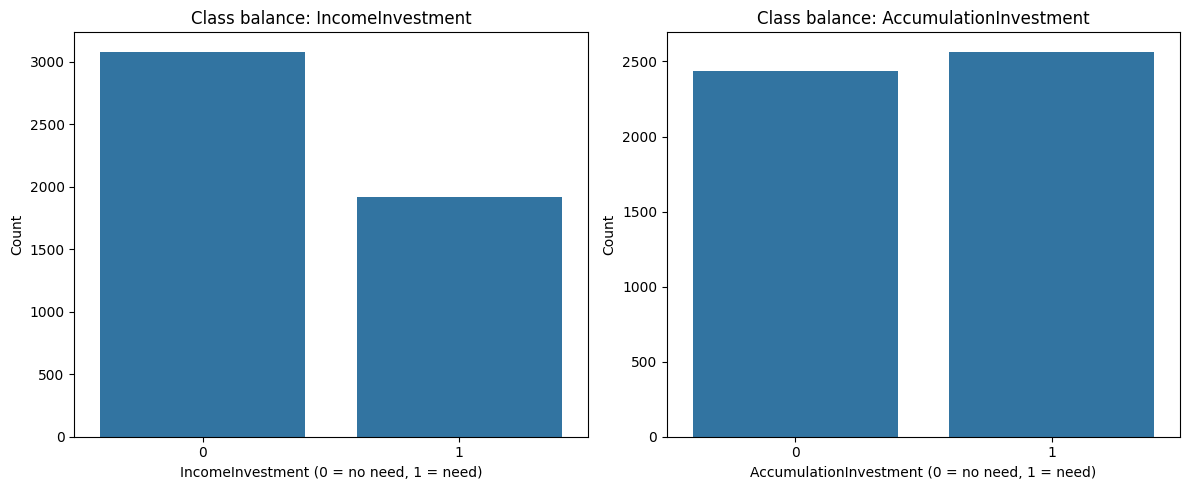

IncomeInvestment proportions:
IncomeInvestment
0    0.6164
1    0.3836
Name: proportion, dtype: float64

AccumulationInvestment proportions:
AccumulationInvestment
0    0.4868
1    0.5132
Name: proportion, dtype: float64


In [6]:
# In this phase, we aim to examine how the target variables are distributed, that is, how many clients have (value 1) or do not have (value 0) 
# a given investment need. This is important because a strong class imbalance could negatively affect the model’s performance.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='IncomeInvestment', data=needs_df, ax=axes[0])
axes[0].set_title('Class balance: IncomeInvestment')
axes[0].set_xlabel('IncomeInvestment (0 = no need, 1 = need)')
axes[0].set_ylabel('Count')

sns.countplot(x='AccumulationInvestment', data=needs_df, ax=axes[1])
axes[1].set_title('Class balance: AccumulationInvestment')
axes[1].set_xlabel('AccumulationInvestment (0 = no need, 1 = need)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Relative frequencies
print("IncomeInvestment proportions:")
print(needs_df['IncomeInvestment'].value_counts(normalize=True).sort_index())

print("\nAccumulationInvestment proportions:")
print(needs_df['AccumulationInvestment'].value_counts(normalize=True).sort_index())

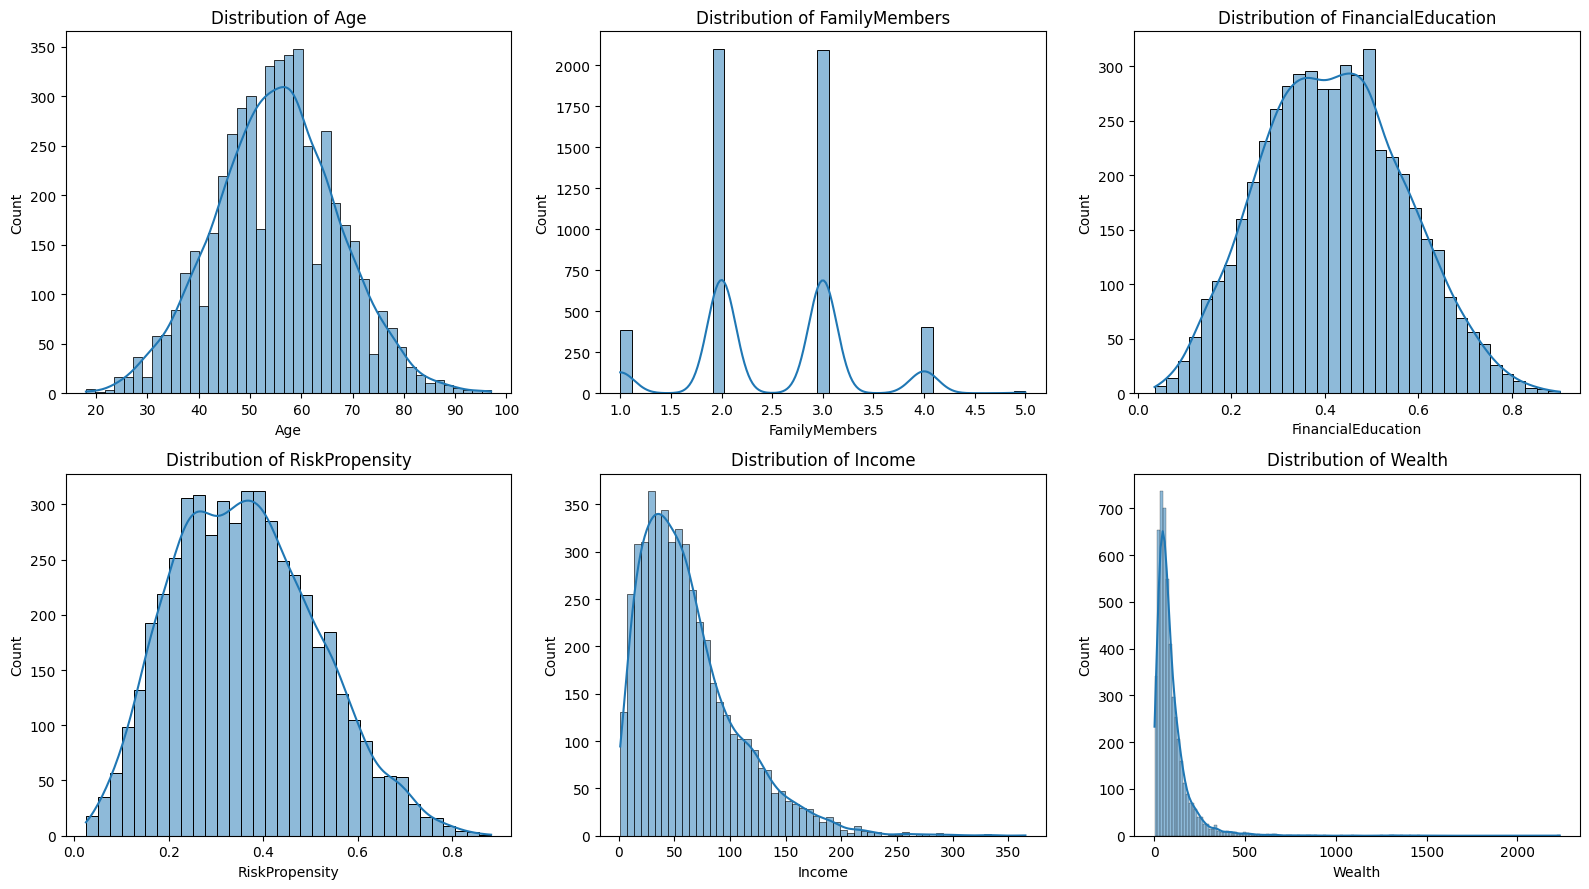

In [7]:
# rapid check to see overall distribution of all variables (and understand if they can be considered discrete)

numeric_features = ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Income', 'Wealth']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(needs_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

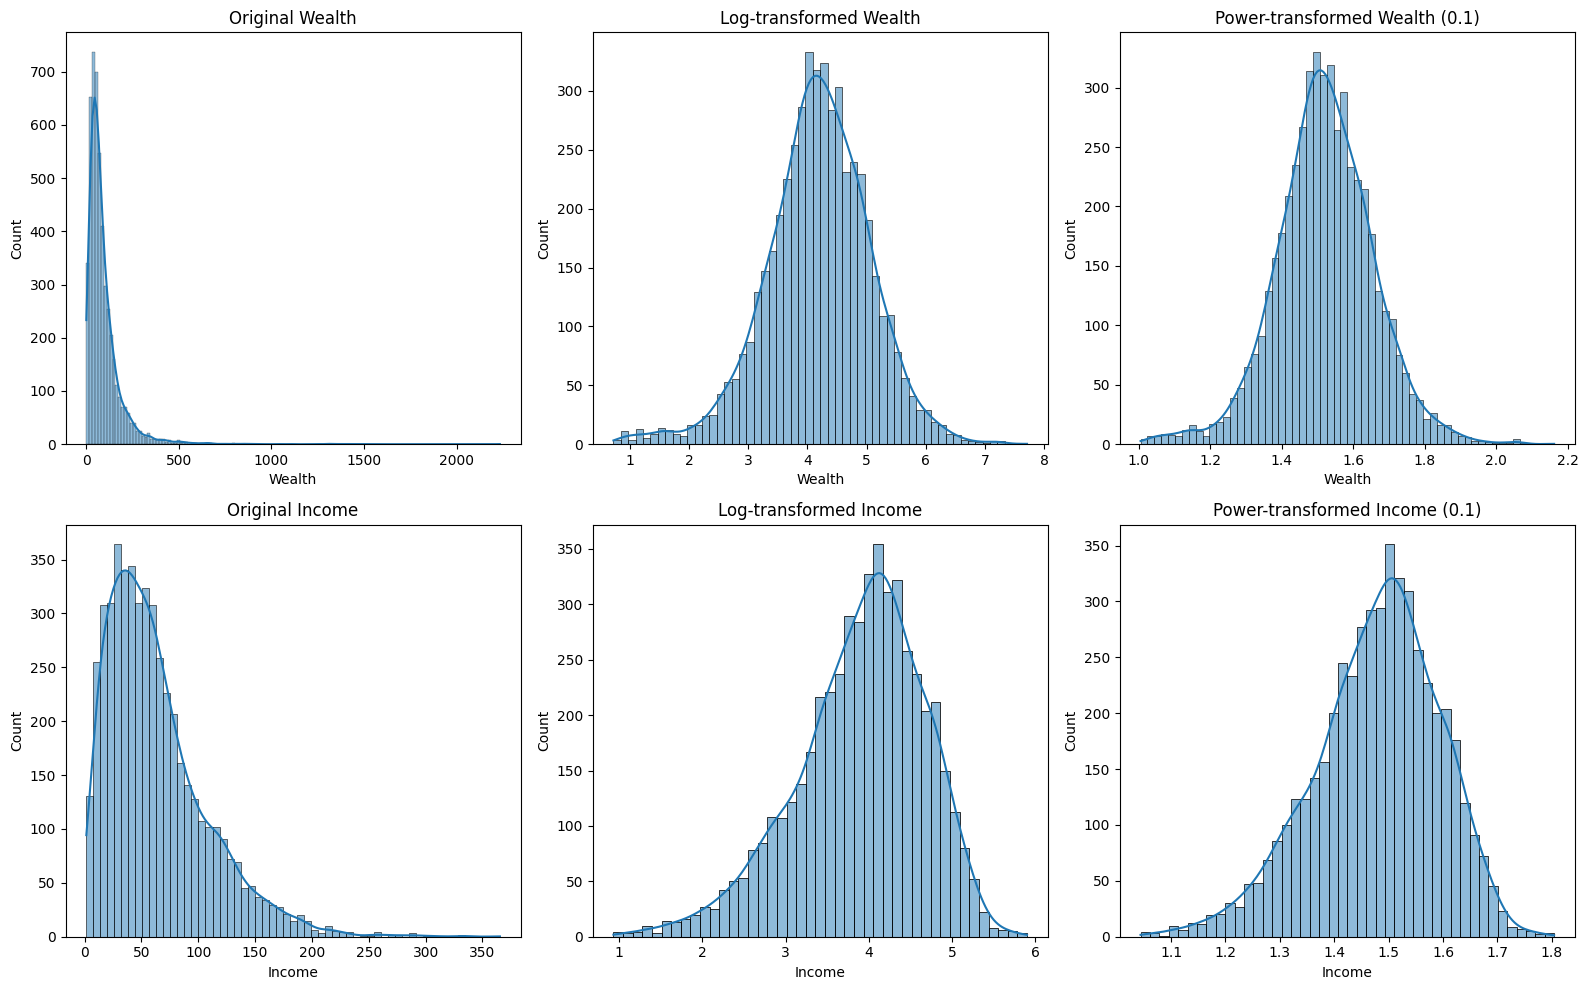

In [8]:
# we log-transform and power-transform both wealth and income since they seem skewed

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Wealth
sns.histplot(needs_df['Wealth'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original Wealth')

sns.histplot(np.log1p(needs_df['Wealth']), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Log-transformed Wealth')

sns.histplot(np.power(needs_df['Wealth'], 0.1), kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Power-transformed Wealth (0.1)')

# Income
sns.histplot(needs_df['Income'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Original Income')

sns.histplot(np.log1p(needs_df['Income']), kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Log-transformed Income')

sns.histplot(np.power(needs_df['Income'], 0.1), kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Power-transformed Income (0.1)')

plt.tight_layout()
plt.show()




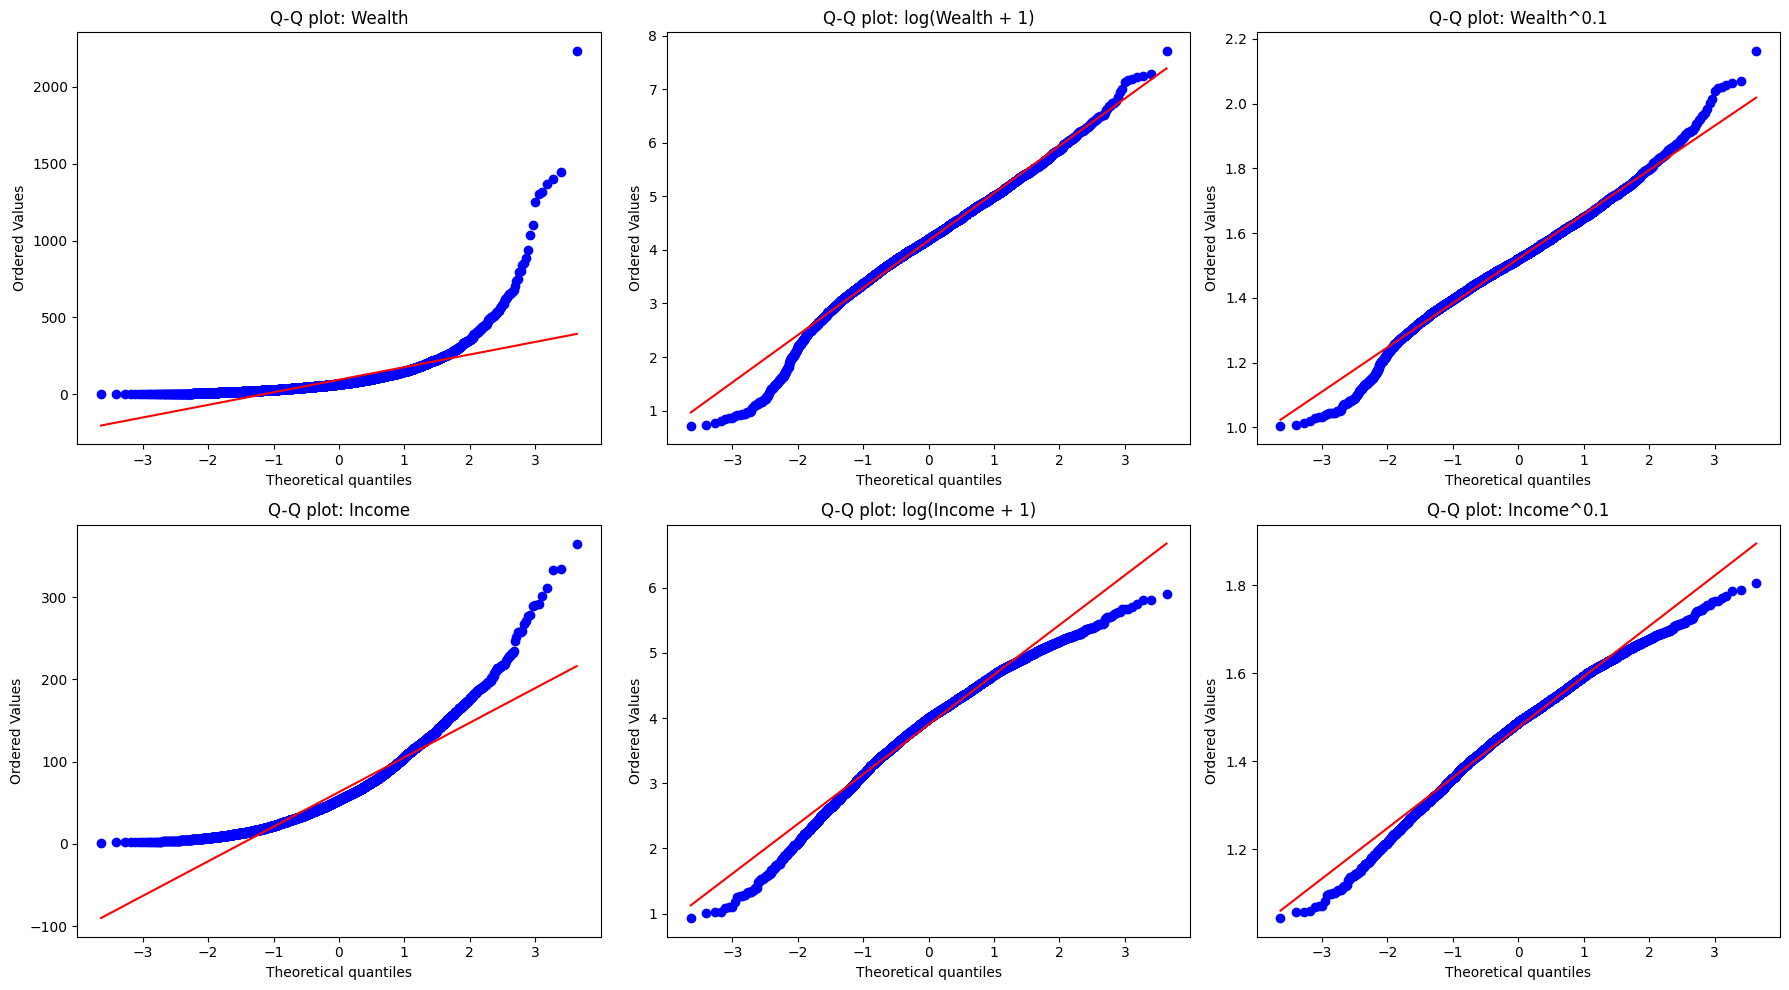

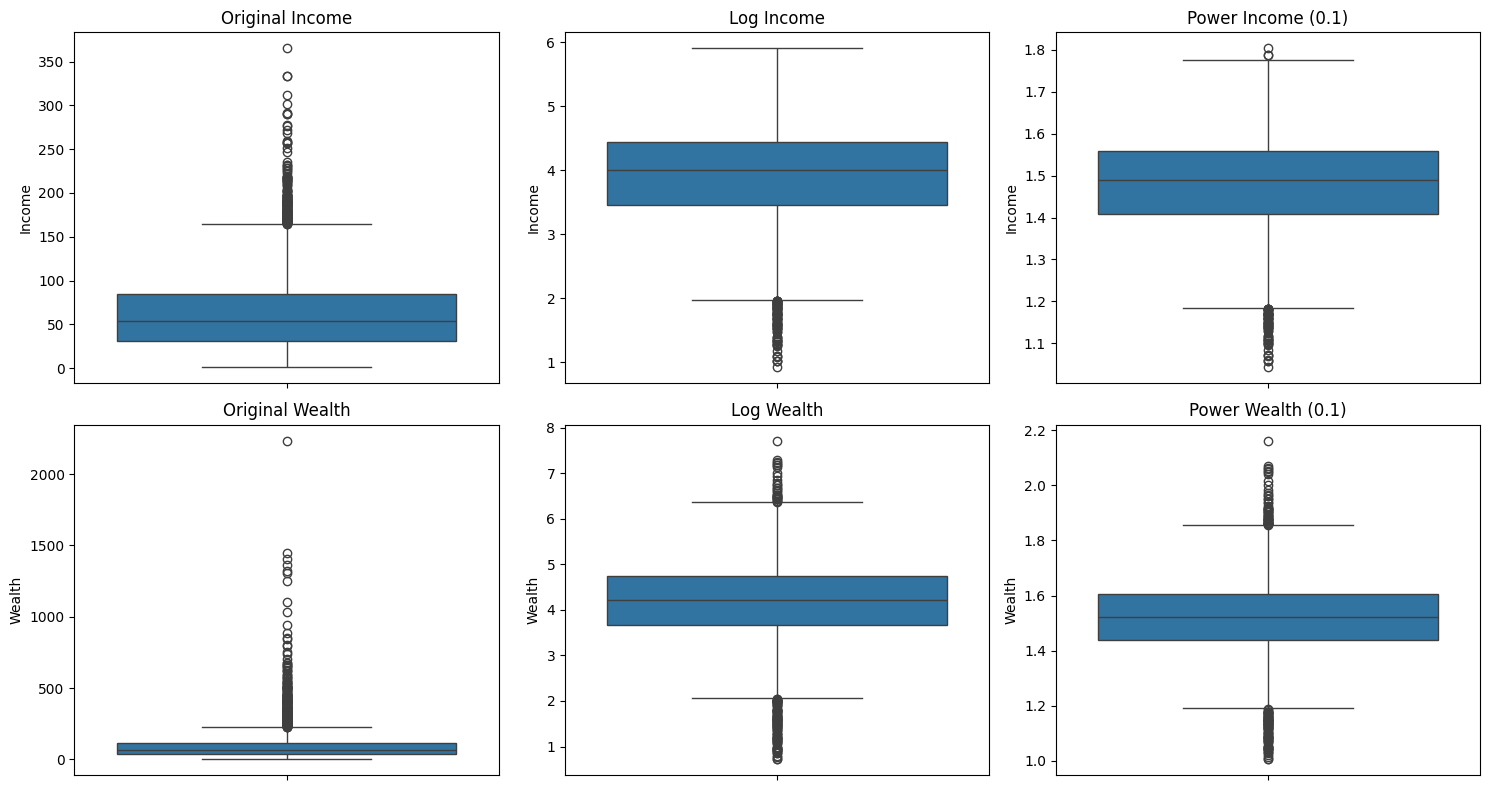

In [9]:
# we check if the transformations applied to the variables studied above, actually reduce skewness and heavy tails 
# (Q-Q plot for comparison with normal distribution, before and after transformations) + boxplot for visual check of outliers

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Wealth
stats.probplot(needs_df['Wealth'], dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q plot: Wealth')

stats.probplot(np.log1p(needs_df['Wealth']), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q plot: log(Wealth + 1)')

stats.probplot(np.power(needs_df['Wealth'], 0.1), dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q plot: Wealth^0.1')

# Income
stats.probplot(needs_df['Income'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot: Income')

stats.probplot(np.log1p(needs_df['Income']), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot: log(Income + 1)')

stats.probplot(np.power(needs_df['Income'], 0.1), dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q plot: Income^0.1')

plt.tight_layout()
plt.show()
plt.show()



fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Income
sns.boxplot(y=needs_df['Income'], ax=axes[0, 0])
axes[0, 0].set_title('Original Income')

sns.boxplot(y=np.log1p(needs_df['Income']), ax=axes[0, 1])
axes[0, 1].set_title('Log Income')

sns.boxplot(y=np.power(needs_df['Income'], 0.1), ax=axes[0, 2])
axes[0, 2].set_title('Power Income (0.1)')

# Wealth
sns.boxplot(y=needs_df['Wealth'], ax=axes[1, 0])
axes[1, 0].set_title('Original Wealth')

sns.boxplot(y=np.log1p(needs_df['Wealth']), ax=axes[1, 1])
axes[1, 1].set_title('Log Wealth')

sns.boxplot(y=np.power(needs_df['Wealth'], 0.1), ax=axes[1, 2])
axes[1, 2].set_title('Power Wealth (0.1)')

plt.tight_layout()
plt.show()

In [10]:
# construction of the new dataset, keeping only the log-transformed versions of wealth and income, since they seem to perform better 

transformed_df = needs_df.copy()

# Log transformations
transformed_df['Wealth_log'] = np.log1p(transformed_df['Wealth'])
transformed_df['Income_log'] = np.log1p(transformed_df['Income'])


# Min-max scaling on selected continuous predictors
scaler = MinMaxScaler()
vars_to_scale = [
    'Age', 
    'RiskPropensity', 
    'FinancialEducation', 
    'Wealth_log', 
    'Income_log',
]

transformed_df[vars_to_scale] = scaler.fit_transform(transformed_df[vars_to_scale])


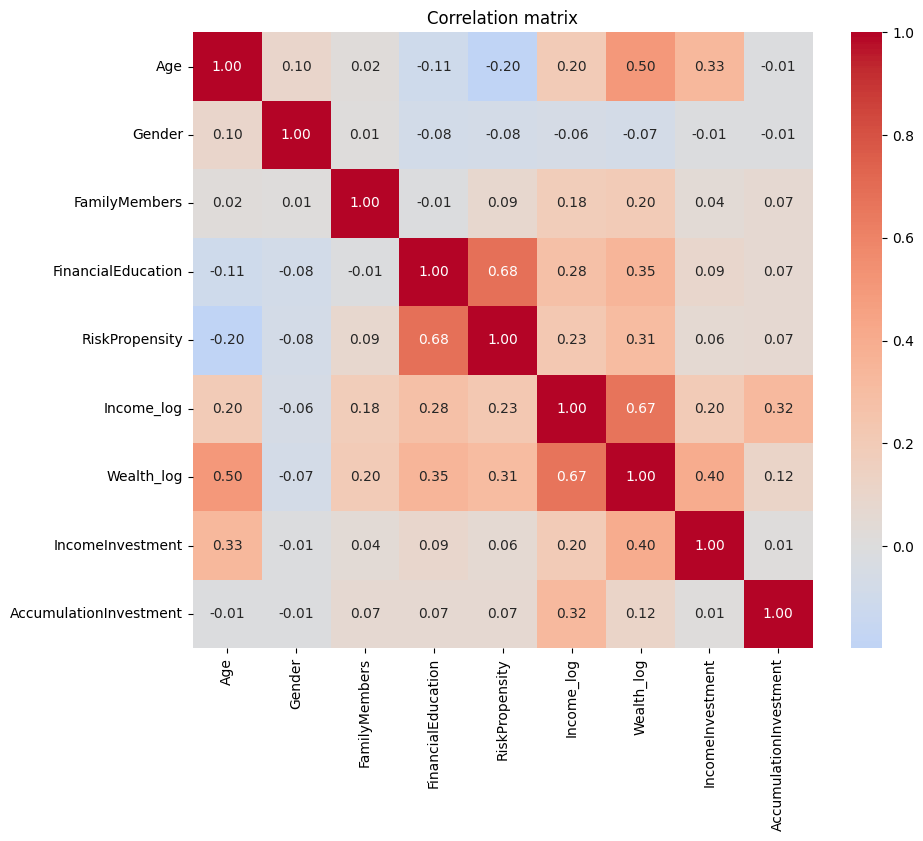

In [11]:
# Some plots to check the new distributions after transformations and scaling, to verify that they are now more suitable for modeling 

# Correlation matrix
corr_cols = [
    'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
    'RiskPropensity', 'Income_log', 'Wealth_log',
    'IncomeInvestment', 'AccumulationInvestment'
]

plt.figure(figsize=(10, 8))
sns.heatmap(transformed_df[corr_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title('Correlation matrix')
plt.show()

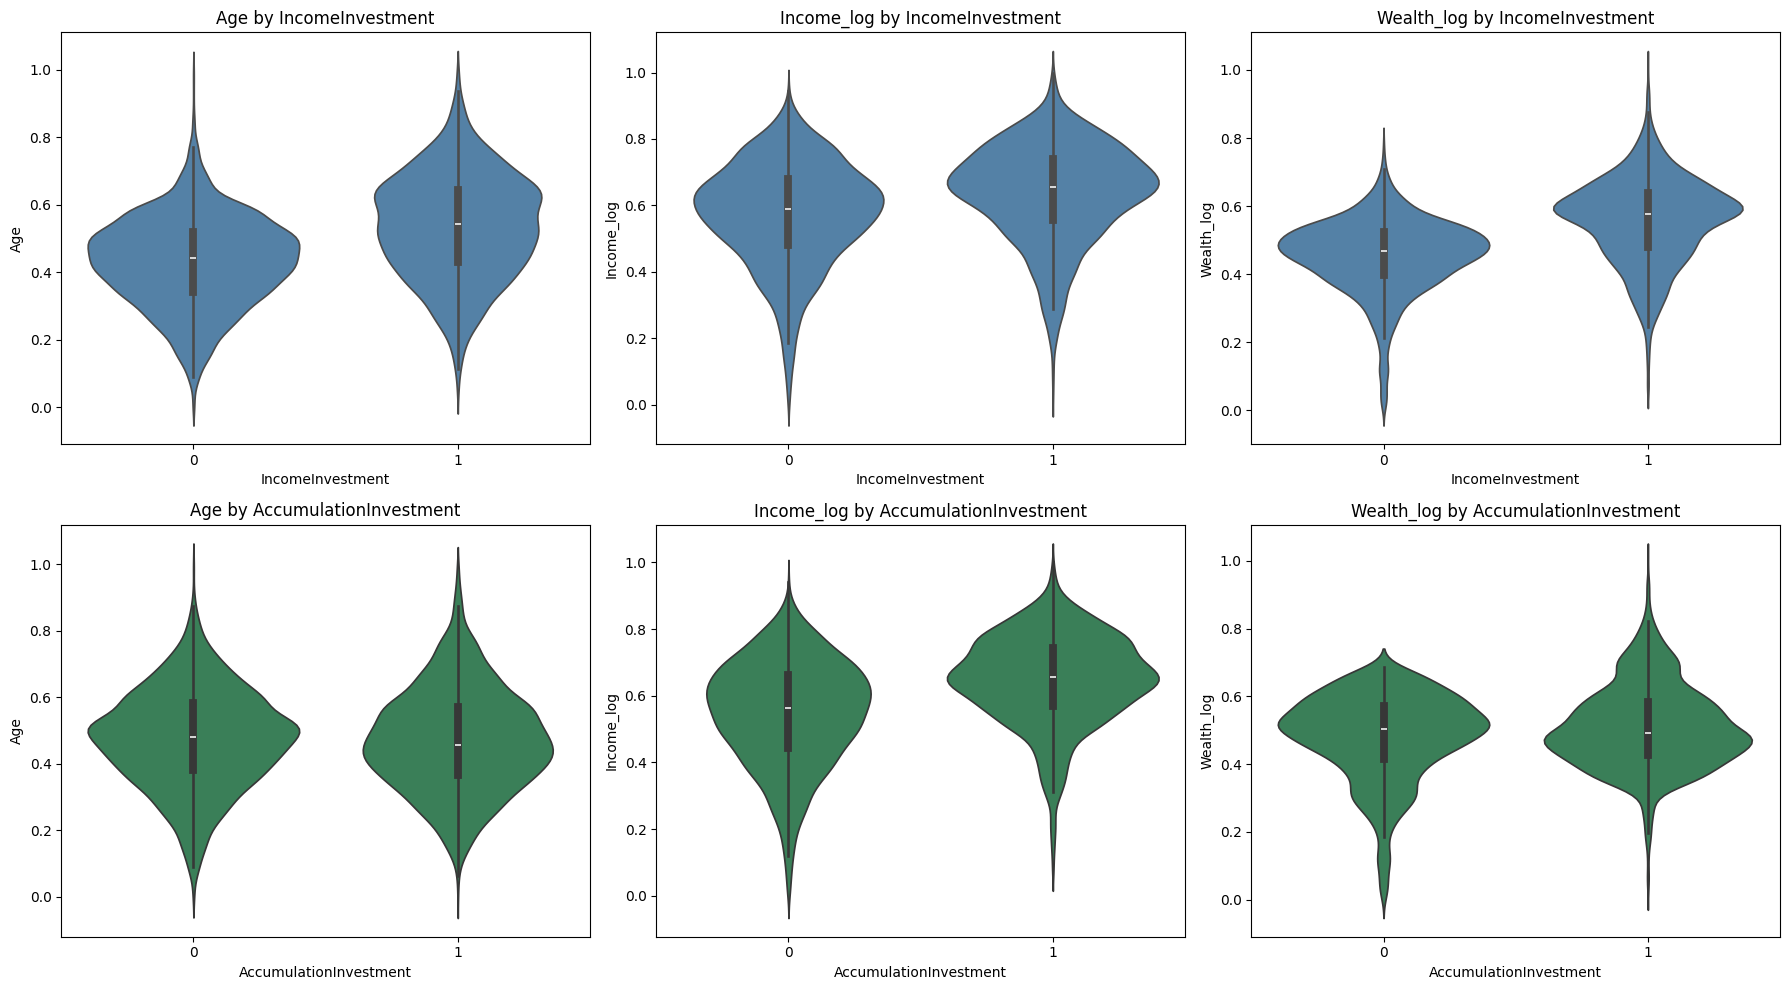

In [12]:
# Violin plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = ['Age', 'Income_log', 'Wealth_log']

# IncomeInvestment
for i, var in enumerate(variables):
    sns.violinplot(
        x='IncomeInvestment',
        y=var,
        data=transformed_df,
        ax=axes[0, i],
        color='steelblue'   
    )
    axes[0, i].set_title(f'{var} by IncomeInvestment')

# AccumulationInvestment
for i, var in enumerate(variables):
    sns.violinplot(
        x='AccumulationInvestment',
        y=var,
        data=transformed_df,
        ax=axes[1, i],
        color='seagreen'  
    )
    axes[1, i].set_title(f'{var} by AccumulationInvestment')

plt.tight_layout()
plt.show()

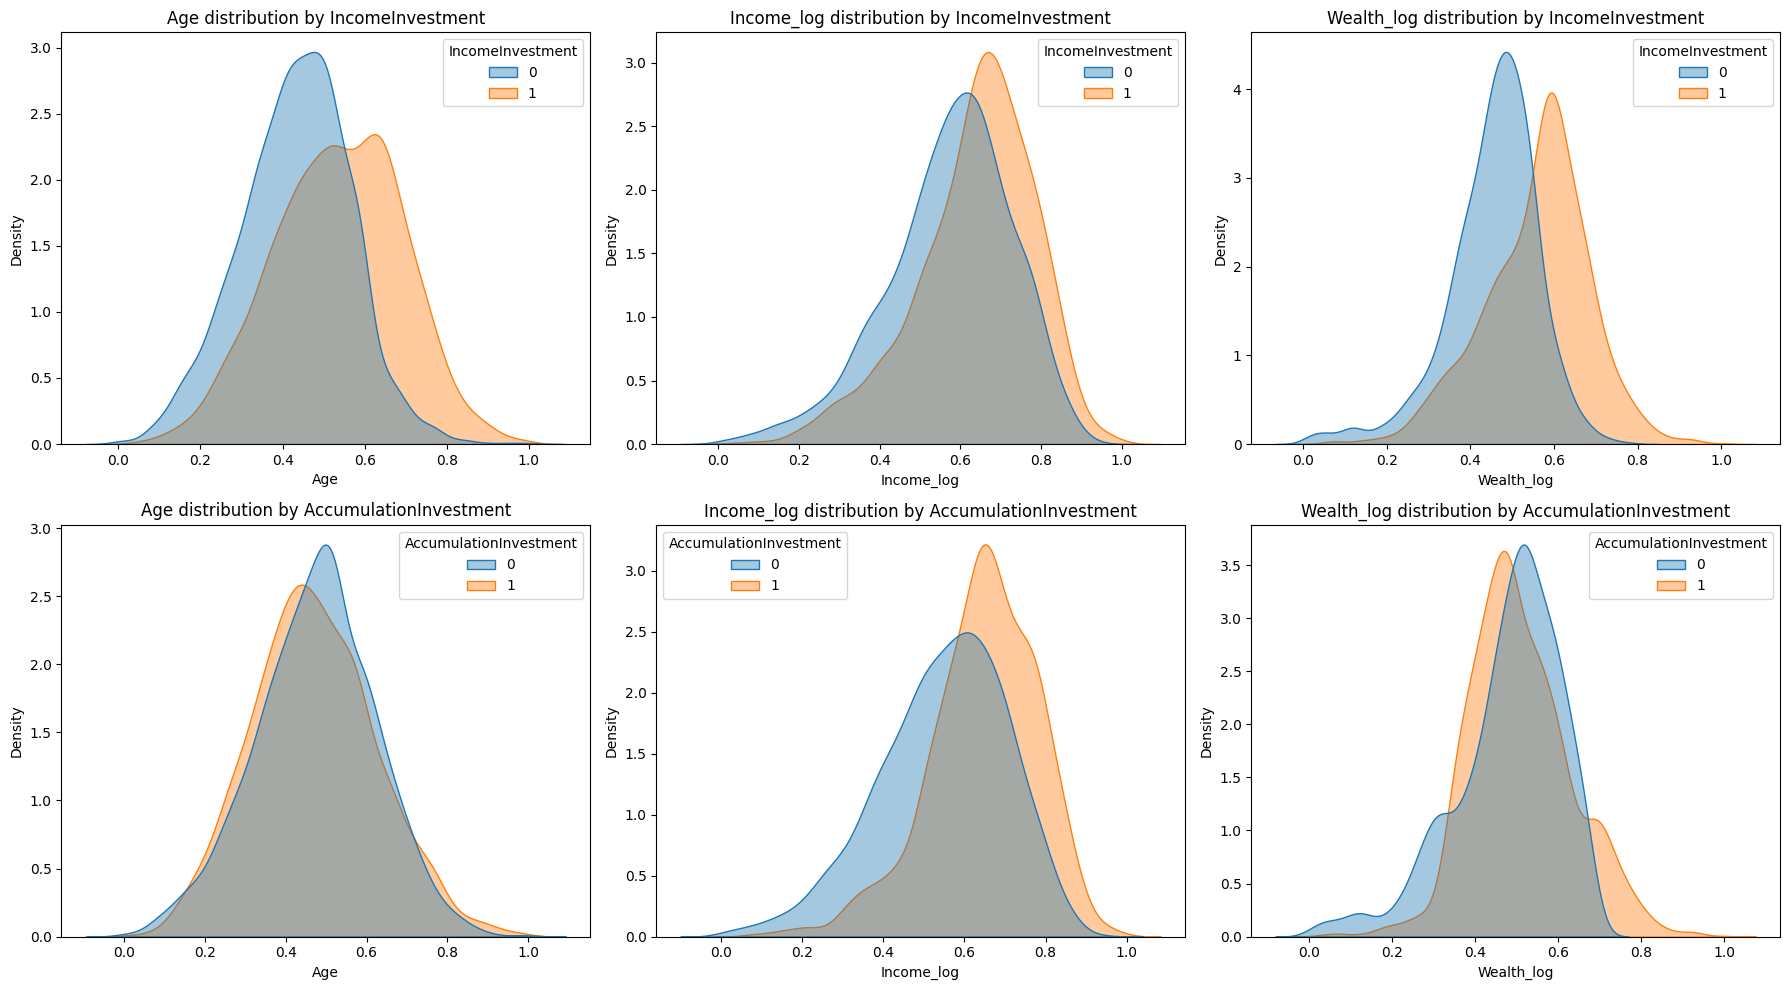

In [13]:
# KDE plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = ['Age', 'Income_log', 'Wealth_log']

# IncomeInvestment
for i, var in enumerate(variables):
    sns.kdeplot(
        data=transformed_df,
        x=var,
        hue='IncomeInvestment',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f'{var} distribution by IncomeInvestment')

# AccumulationInvestment 
for i, var in enumerate(variables):
    sns.kdeplot(
        data=transformed_df,
        x=var,
        hue='AccumulationInvestment',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[1, i]
    )
    axes[1, i].set_title(f'{var} distribution by AccumulationInvestment')

plt.tight_layout()
plt.show()

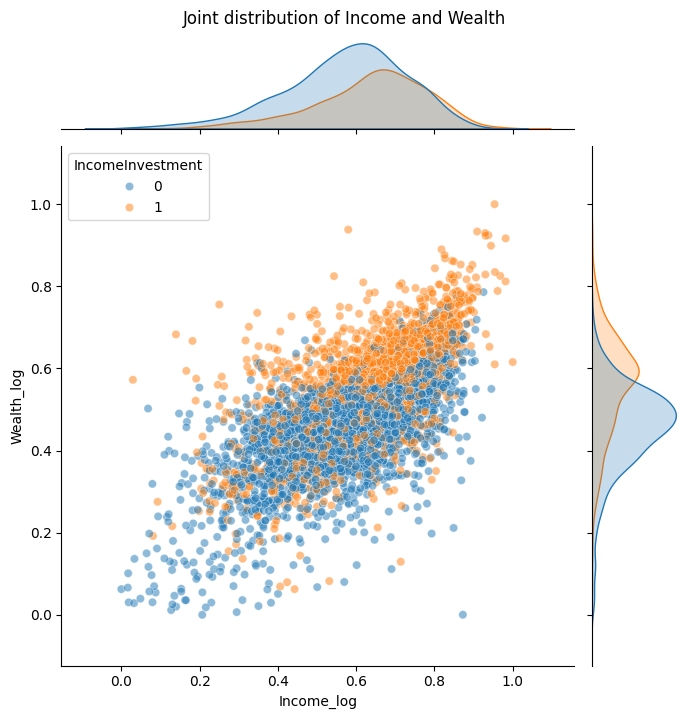

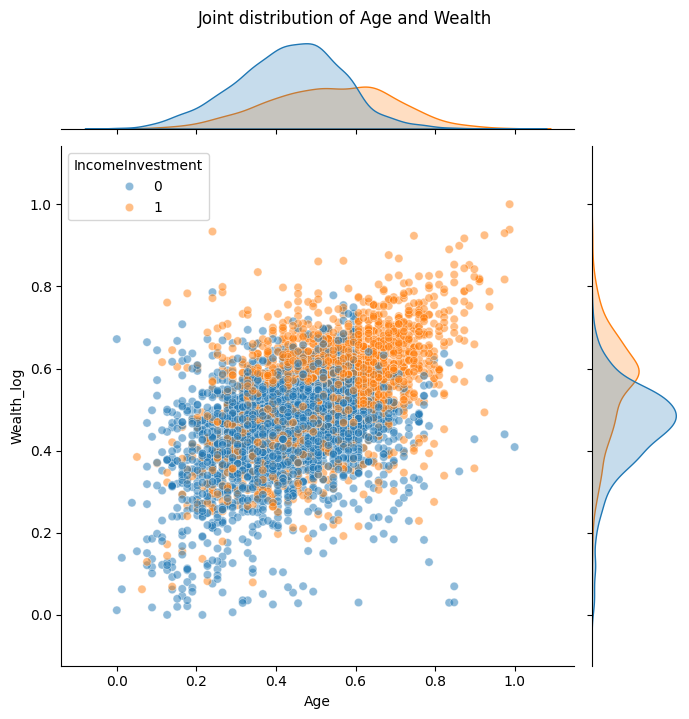

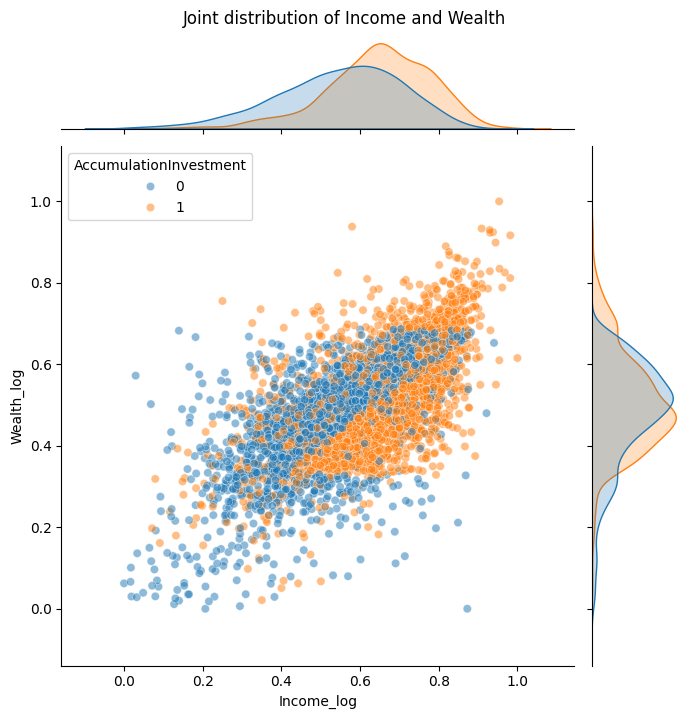

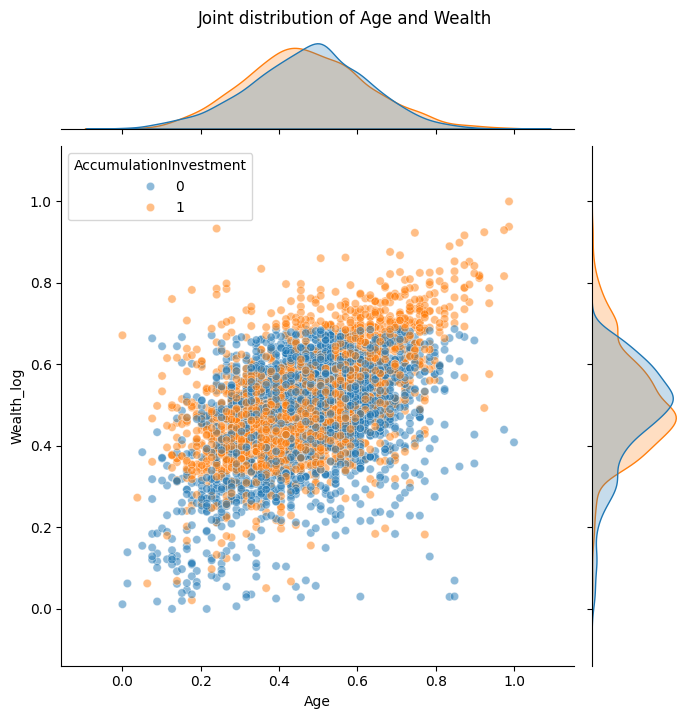

In [14]:
# Plots that help to understand the fundamental relationships between the variables of our interest, also distinguishing based on the target classes
sns.jointplot(data=transformed_df, x='Income_log', y='Wealth_log', kind='scatter', hue='IncomeInvestment', alpha=0.5, height=7)
plt.suptitle('Joint distribution of Income and Wealth', y=1.02)
plt.show()

sns.jointplot(data=transformed_df, x='Age', y='Wealth_log', kind='scatter', hue='IncomeInvestment', alpha=0.5, height=7)
plt.suptitle('Joint distribution of Age and Wealth', y=1.02)
plt.show()

sns.jointplot(data=transformed_df, x='Income_log', y='Wealth_log', kind='scatter', hue='AccumulationInvestment', alpha=0.5, height=7)
plt.suptitle('Joint distribution of Income and Wealth', y=1.02)
plt.show()

sns.jointplot(data=transformed_df, x='Age', y='Wealth_log', kind='scatter', hue='AccumulationInvestment', alpha=0.5, height=7)
plt.suptitle('Joint distribution of Age and Wealth', y=1.02)
plt.show()

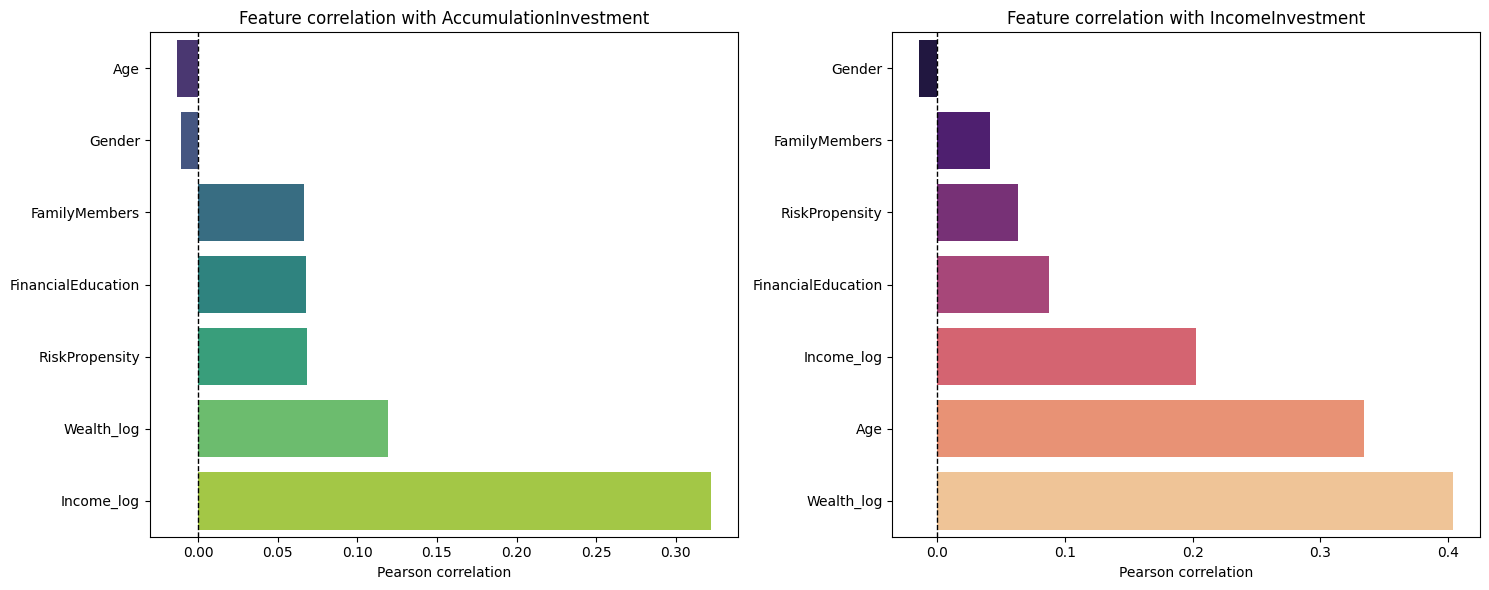

In [15]:
# Target correlation bar plots
corr_matrix = transformed_df[corr_cols].corr()

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)

accum_corr = corr_matrix['AccumulationInvestment'].drop(
    ['AccumulationInvestment', 'IncomeInvestment']
).sort_values()

sns.barplot(
    x=accum_corr.values,
    y=accum_corr.index,
    hue=accum_corr.index,
    legend=False,
    palette="viridis"
)
plt.title('Feature correlation with AccumulationInvestment')
plt.xlabel('Pearson correlation')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)


plt.subplot(1, 2, 2)
income_corr = corr_matrix['IncomeInvestment'].drop(
    ['AccumulationInvestment', 'IncomeInvestment']
).sort_values()

sns.barplot(
    x=income_corr.values,
    y=income_corr.index,
    hue=income_corr.index,
    legend=False,
    palette="magma"
)
plt.title('Feature correlation with IncomeInvestment')
plt.xlabel('Pearson correlation')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

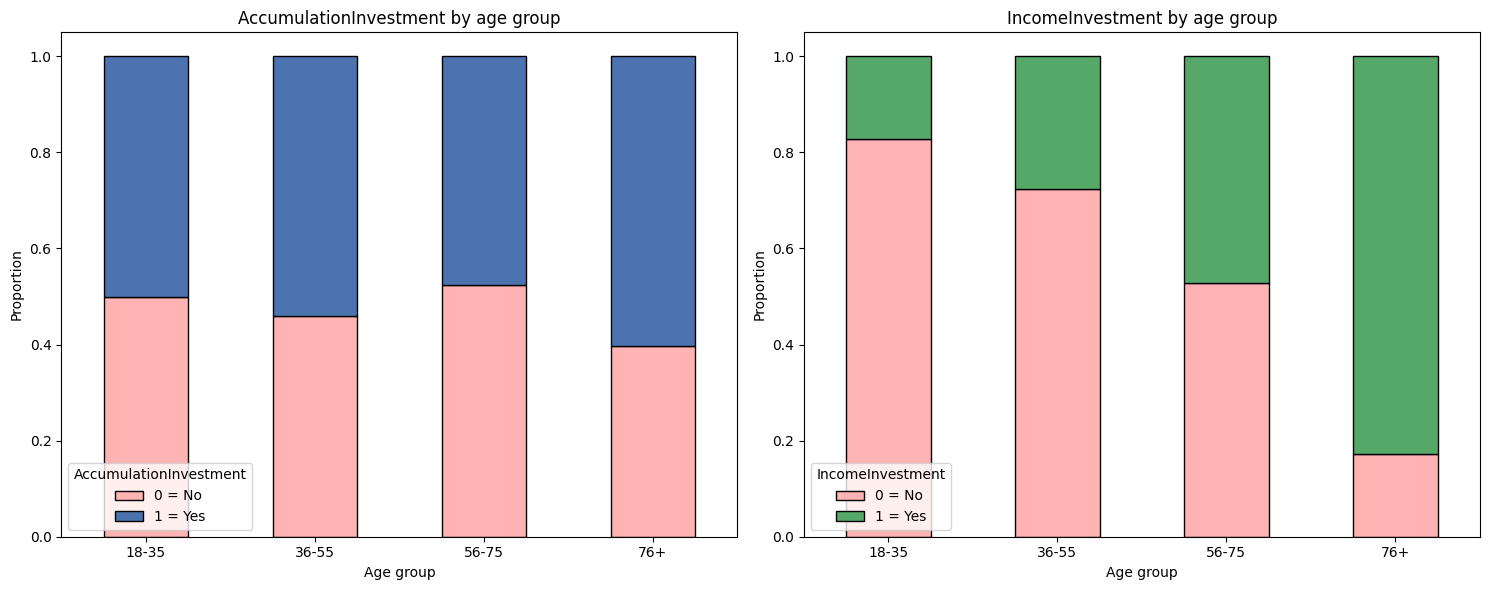

In [16]:
# Stacked bar charts: Age group analysis

temp_df = transformed_df.copy()

temp_df['Age_Group'] = pd.cut(
    needs_df['Age'],
    bins=[17, 35, 55, 75, 100],
    labels=['18-35', '36-55', '56-75', '76+']
)

age_accum_prop = (
    temp_df.groupby('Age_Group', observed=False)['AccumulationInvestment']
    .value_counts(normalize=True)
    .unstack()
)

age_income_prop = (
    temp_df.groupby('Age_Group', observed=False)['IncomeInvestment']
    .value_counts(normalize=True)
    .unstack()
)

plt.figure(figsize=(15, 6))

# AccumulationInvestment
ax1 = plt.subplot(1, 2, 1)
age_accum_prop.plot(
    kind='bar',
    stacked=True,
    color=['#ffb3b3', '#4c72b0'],
    edgecolor='black',
    ax=ax1
)
ax1.set_title('AccumulationInvestment by age group')
ax1.set_xlabel('Age group')
ax1.set_ylabel('Proportion')
ax1.legend(title='AccumulationInvestment', labels=['0 = No', '1 = Yes'], loc='lower left')
ax1.tick_params(axis='x', rotation=0)

# IncomeInvestment
ax2 = plt.subplot(1, 2, 2)
age_income_prop.plot(
    kind='bar',
    stacked=True,
    color=['#ffb3b3', '#55a868'],
    edgecolor='black',
    ax=ax2
)
ax2.set_title('IncomeInvestment by age group')
ax2.set_xlabel('Age group')
ax2.set_ylabel('Proportion')
ax2.legend(title='IncomeInvestment', labels=['0 = No', '1 = Yes'], loc='lower left')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Train and evaluate baseline classifiers
Prepare features, run cross-validated SVM/Naive Bayes training, and report metrics with ROC curves.


Target Variable: Income Investment

SVM - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  | 0.7827500000000001 | 0.017237314175938222 |  0.764   |
| 1 | Precision | 0.8322028075117138 | 0.020560096163658306 |  0.827   |
| 2 |  Recall   | 0.5423729535245151 | 0.03960037201648322  |  0.487   |
| 3 |    F1     | 0.6562269465287243 | 0.034108044499821084 |  0.613   |
| 4 |    AUC    |         -          |          -           |   0.74   |
+---+-----------+--------------------+----------------------+----------+

SVM - Engineered Features
+---+-----------+--------------------+---------------------+----------+
|   |  Metric   |      CV Mean       |       CV Std        | Test Set |
+---+-----------+--------------------+---------------------+----------+
| 0 | Accuracy  |      0.78825       | 0.01

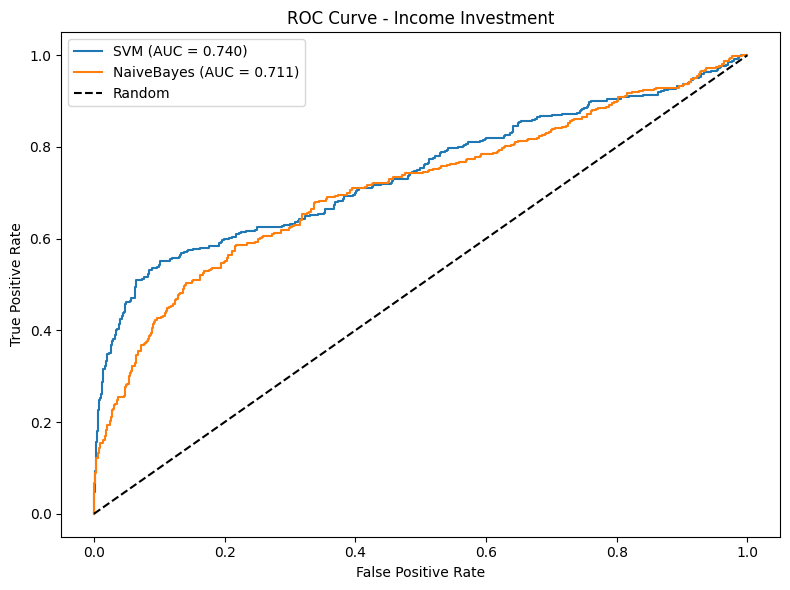


Target Variable: Accumulation Investment

SVM - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  | 0.7542500000000001 | 0.01974208702239962  |  0.747   |
| 1 | Precision | 0.7871454585849318 | 0.02133642354252533  |  0.764   |
| 2 |  Recall   | 0.7145759895555159 | 0.02238566238689773  |  0.733   |
| 3 |    F1     | 0.7490094503945837 | 0.020281871352548584 |  0.748   |
| 4 |    AUC    |         -          |          -           |   0.8    |
+---+-----------+--------------------+----------------------+----------+

SVM - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |      0.76525    

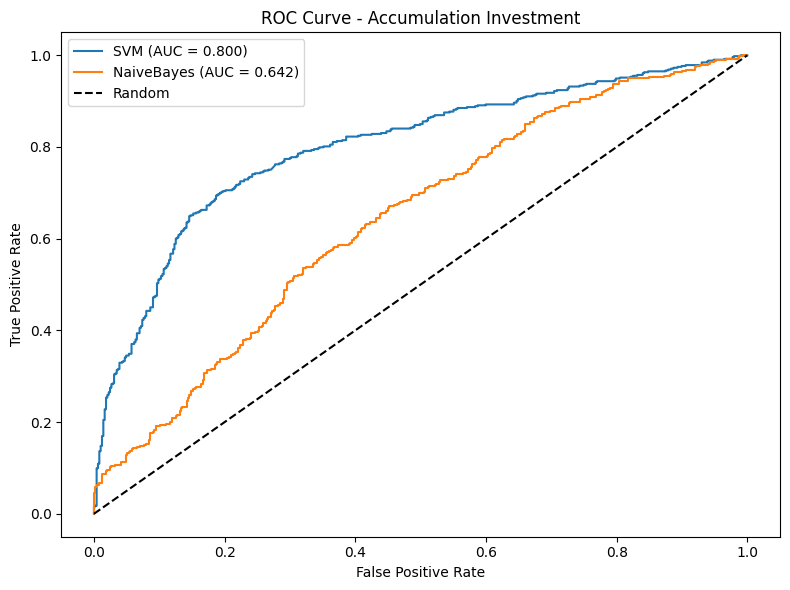

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import PowerTransformer, StandardScaler

def prepare_features(df):
    X = df.copy()

    # Normalize column name
    if 'Income ' in X.columns:
        X = X.rename(columns={'Income ': 'Income'})

    # 1. Log transformations (Keep these as they help the scaler)
    X['Wealth_log'] = np.log1p(X['Wealth'])
    X['Income_log'] = np.log1p(X['Income'])

    # 2. Ratio features
    X['Income_Wealth_Ratio'] = X['Income'] / X['Wealth'].replace(0, np.nan)
    X['Income_Wealth_Ratio'] = X['Income_Wealth_Ratio'].fillna(X['Income'].max())
    X['Income_Wealth_Ratio_log'] = np.log1p(X['Income_Wealth_Ratio'])

    # 3. Risk interaction features
    X['Income_Risk']  = X['Income_log'] * X['RiskPropensity']
    X['Wealth_Risk']  = X['Wealth_log'] * X['RiskPropensity']
    X['FinEdu_Risk']  = X['FinancialEducation'] * X['RiskPropensity']

    # 4. Lifecycle features
    X['years_to_retire'] = (65 - X['Age']).clip(lower=0)
    X['wealth_per_year'] = X['Wealth_log'] / (X['years_to_retire'] + 1)

    X['Income_per_Family'] = X['Income_log'] / X['FamilyMembers'].replace(0, np.nan)
    X['Income_per_Family'] = X['Income_per_Family'].fillna(X['Income_log'].max())
    X['Wealth_Income_Ratio'] = X['Wealth_log'] / (X['Income'] + 1)

    features_base = [
        'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
        'RiskPropensity', 'Wealth_log', 'Income_log'
    ]
    features_engineered = [
        'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
        'RiskPropensity', 'Wealth_log', 'Income_log',
        'Income_Wealth_Ratio_log',
        'Income_Risk', 'Wealth_Risk', 'FinEdu_Risk', 'Wealth_Income_Ratio'
    ]

    
    scaler = PowerTransformer(method='yeo-johnson')

    X_base       = pd.DataFrame(scaler.fit_transform(X[features_base]),       columns=features_base,       index=X.index)
    X_engineered = pd.DataFrame(scaler.fit_transform(X[features_engineered]), columns=features_engineered, index=X.index)

    return X_base, X_engineered
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train,y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)
        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    return {
        'model': model,
        'cv_metrics': {
            metric: {'mean': np.mean(scores), 'std': np.std(scores)}
            for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy':  accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall':    recall_score(y_test, y_test_pred),
            'f1':        f1_score(y_test, y_test_pred),
            'auc':       roc_auc_score(y_test, y_test_proba)
        },
        'y_test_proba': y_test_proba
    }


# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean'],
            '-'
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std'],
            '-'
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1'],
            results_dict['test_metrics']['auc']
        ]
    }
    df = pd.DataFrame(cv_data)
    df = df.round(3)
    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))


# Step 5: Run full analysis
X_base, X_engineered = prepare_features(needs_df)
y_income = needs_df['IncomeInvestment']
y_accum  = needs_df['AccumulationInvestment']

models = {
    'SVM':        SVC(probability=True),
    'NaiveBayes': GaussianNB()
}

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train,  X_eng_test,  _,       _      = split_data(X_engineered, y)

    all_results = {}
    for model_name, model in models.items():
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")

        results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
        display_results_table(results_eng, model_name, "Engineered Features")

        all_results[model_name] = results_base

    plt.figure(figsize=(8, 6))
    for model_name, results in all_results.items():
        fpr, tpr, _ = roc_curve(y_test, results['y_test_proba'])
        auc = results['test_metrics']['auc']
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {target_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

## XGBoost benchmark
Train and evaluate an XGBoost classifier on base and engineered features.

In [18]:
import xgboost as xgb

# Updated XGBoost configuration
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    model = models['XGBoost']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'XGBoost', "Base Features")

    results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
    display_results_table(results_eng, 'XGBoost', "Engineered Features")



Target Variable: Income Investment

XGBoost - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |      0.78975       | 0.012283118496538244 |  0.763   |
| 1 | Precision | 0.7869796327642041 | 0.027264268034811173 |  0.765   |
| 2 |  Recall   | 0.6205978156735006 | 0.02179130105811132  |  0.552   |
| 3 |    F1     | 0.6935799528437123 | 0.017663135957515907 |  0.641   |
| 4 |    AUC    |         -          |          -           |  0.752   |
+---+-----------+--------------------+----------------------+----------+

XGBoost - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |       0.8055  

## Random Forest benchmark
Train and evaluate a Random Forest model for both target variables.

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Updated Rf configuration
models = {
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        criterion='gini',
        class_weight={0: 1.0, 1: 1.6}
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train, X_eng_test, _, _ = split_data(X_engineered, y)

    model = models['RandomForest']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'RandomForest', "Base Features")

    results_eng = train_evaluate_model(X_eng_train, y_train, X_eng_test, y_test, model)
    display_results_table(results_eng, 'RandomForest', "Engineered Features")



Target Variable: Income Investment

RandomForest - Base Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |       0.812        | 0.010356157588603978 |  0.773   |
| 1 | Precision | 0.8501370985870139 | 0.017781790612989457 |  0.815   |
| 2 |  Recall   | 0.619301270996998  | 0.02720697604431496  |  0.529   |
| 3 |    F1     | 0.7161676297392081 | 0.019202555346594298 |  0.641   |
| 4 |    AUC    |         -          |          -           |  0.769   |
+---+-----------+--------------------+----------------------+----------+

RandomForest - Engineered Features
+---+-----------+--------------------+----------------------+----------+
|   |  Metric   |      CV Mean       |        CV Std        | Test Set |
+---+-----------+--------------------+----------------------+----------+
| 0 | Accuracy  |     

## Interpretability helper functions
Define reusable training output and feature-importance plotting utilities.

In [20]:
# Rewrite the function, returning the trained model, too
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        },
        'model': model
    }


# Feature importance function: capture the trained models during our initial
# training phase and then use them for feature importance analysis
def plot_feature_importance(model, feature_names, title):
    importances = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    importances = importances.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='importance', y='feature')
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()


## Global SHAP summaries
SHAP summary plots to explain global feature impact for tree-based models.

In [21]:
import shap

def plot_shap_values(model, X, title):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"{title} - Feature Impacts")
    plt.tight_layout()
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Local SHAP explanations
Waterfall-style SHAP explanation for one selected test instance.

In [22]:
def plot_loc_shap_values(model, X, title, instance_idx):
    explainer = shap.TreeExplainer(results['model'])
    shap_explanation = explainer(X_eng_test) 

# For binary classification, take positive class
    if len(shap_explanation.shape) == 3:
     shap_explanation = shap_explanation[:, :, 1]

    shap.plots.waterfall(shap_explanation[instance_idx], show=False)
    plt.title(f"{title} - SHAP Waterfall for {instance_idx}th Test Instance")
    plt.tight_layout()
    plt.show()


## Local LIME explanations
LIME-based local interpretability for an individual prediction.

In [23]:
#LIME for local interpretability
from lime.lime_tabular import LimeTabularExplainer


def plot_loc_lime_values(model, X, title, instance_idx):
    explainer_lime = LimeTabularExplainer(
    training_data=X_eng_train.values,
    feature_names=X_engineered.columns.tolist(),
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

    explanation = explainer_lime.explain_instance(
    data_row=X_eng_test.iloc[instance_idx].values,
    predict_fn=results['model'].predict_proba,
    num_features=len(X_engineered.columns)
)

    explanation.as_pyplot_figure()
    plt.title(f"{title} for {instance_idx}th Test Instance")
    plt.tight_layout()
    plt.show()

## Basic MLP implementation
The next cell defines a PyTorch MLP, dataset wrappers, and training loop for both targets.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Detect device — MPS for Apple Silicon, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class InvestmentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values.copy())
        self.y = torch.FloatTensor(y.values.copy())
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        val_loss = 0
        val_preds = []
        val_true = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # move to device
                y_pred = model(X_batch).squeeze()
                val_loss += criterion(y_pred, y_batch).item()
                val_preds.extend((y_pred > 0.5).float().cpu().numpy())  # .cpu() before numpy
                val_true.extend(y_batch.cpu().numpy())                   # .cpu() before numpy
        if (epoch + 1) % 1 == 0:
            print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, '
                  f'Val Loss: {val_loss/len(val_loader):.4f}, '
                  f'Val Accuracy: {accuracy_score(val_true, val_preds):.4f}')

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nTraining Neural Network for {target_name}")
    print("=" * 50)
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128)
    model = MLP(input_size=X_train.shape[1]).to(device)  # move model to device
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(model, train_loader, test_loader, criterion, optimizer)

Using device: mps

Training Neural Network for Income Investment
Epoch 1, Train Loss: 0.6813, Val Loss: 0.6574, Val Accuracy: 0.5640
Epoch 2, Train Loss: 0.6013, Val Loss: 0.6024, Val Accuracy: 0.6990
Epoch 3, Train Loss: 0.5595, Val Loss: 0.5709, Val Accuracy: 0.7430
Epoch 4, Train Loss: 0.5423, Val Loss: 0.5561, Val Accuracy: 0.7440
Epoch 5, Train Loss: 0.5321, Val Loss: 0.5429, Val Accuracy: 0.7500
Epoch 6, Train Loss: 0.5224, Val Loss: 0.5389, Val Accuracy: 0.7560
Epoch 7, Train Loss: 0.5185, Val Loss: 0.5392, Val Accuracy: 0.7500
Epoch 8, Train Loss: 0.5158, Val Loss: 0.5354, Val Accuracy: 0.7570
Epoch 9, Train Loss: 0.5133, Val Loss: 0.5364, Val Accuracy: 0.7590
Epoch 10, Train Loss: 0.5098, Val Loss: 0.5337, Val Accuracy: 0.7620

Training Neural Network for Accumulation Investment
Epoch 1, Train Loss: 0.6550, Val Loss: 0.6319, Val Accuracy: 0.6990
Epoch 2, Train Loss: 0.6152, Val Loss: 0.6031, Val Accuracy: 0.7050
Epoch 3, Train Loss: 0.5929, Val Loss: 0.5829, Val Accuracy: 0.73

## Evaluate neural network performance
The next cell computes confusion matrices and training/test metrics for the trained MLP.


Results for Income Investment


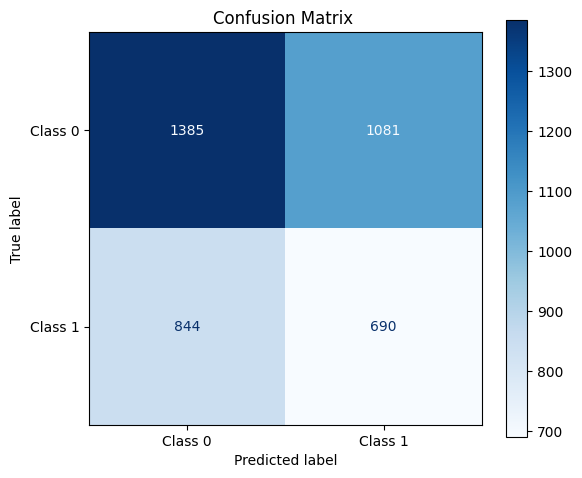

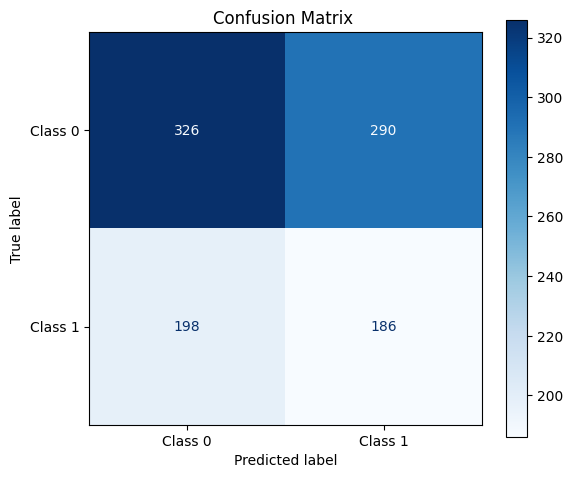


Neural Network Metrics:
           Training   Test
accuracy      0.519  0.512
precision     0.390  0.391
recall        0.450  0.484
f1            0.418  0.433

Results for Accumulation Investment


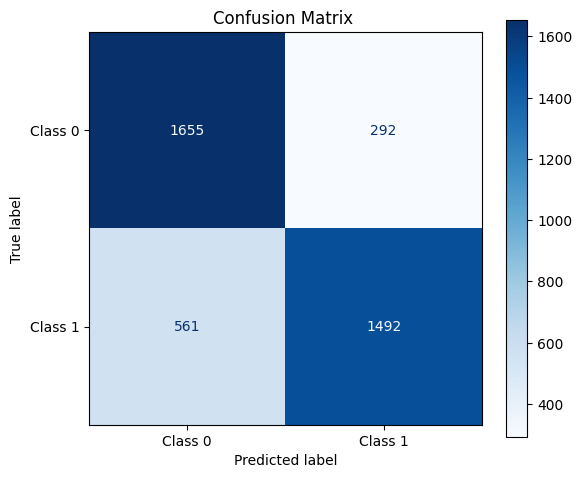

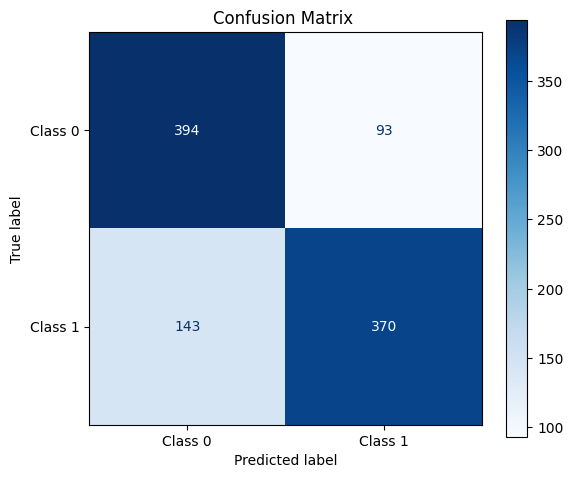


Neural Network Metrics:
           Training   Test
accuracy      0.787  0.764
precision     0.836  0.799
recall        0.727  0.721
f1            0.778  0.758


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def _to_probability(y_raw):
    if globals().get('MLP_OUTPUT_IS_LOGITS', False):
        return torch.sigmoid(y_raw)
    return y_raw

def evaluate_nn_metrics(model, data_loader, title="", threshold=0.5):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_raw = model(X_batch).squeeze()
            y_proba = _to_probability(y_raw)
            all_preds.extend((y_proba > threshold).float().cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_true, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
    plt.figure(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title(f"Confusion Matrix {title}")
    plt.tight_layout()
    plt.show()

    return {
        'accuracy':  accuracy_score(all_true, all_preds),
        'precision': precision_score(all_true, all_preds),
        'recall':    recall_score(all_true, all_preds),
        'f1':        f1_score(all_true, all_preds)
    }

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nResults for {target_name}")
    print("=" * 50)
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    train_dataset = InvestmentDataset(X_train, y_train)
    test_dataset = InvestmentDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128)
    train_metrics = evaluate_nn_metrics(model, train_loader)
    test_metrics = evaluate_nn_metrics(model, test_loader)
    metrics_df = pd.DataFrame({
        'Training': train_metrics,
        'Test': test_metrics
    }).round(3)
    print("\nNeural Network Metrics:")
    print(metrics_df)

## Define Optuna search components
Tunable MLP architecture and Optuna objective/training utilities.

In [26]:
import optuna
from sklearn.metrics import fbeta_score
from optuna.trial import TrialState
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import fbeta_score

# Use logits for numerically stable weighted loss and convert to probabilities only for metrics.
MLP_OUTPUT_IS_LOGITS = True

def _to_probability(y_raw):
    return torch.sigmoid(y_raw) if MLP_OUTPUT_IS_LOGITS else y_raw


class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_weights = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_weights:
            model.load_state_dict(self.best_weights)


class MLP(nn.Module):
    def __init__(self, input_size, layer_sizes, dropouts, use_batchnorm):
        super(MLP, self).__init__()
        layers = []
        in_features = input_size

        for out_features, dropout in zip(layer_sizes, dropouts):
            layers.append(nn.Linear(in_features, out_features))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_features = out_features

        layers.append(nn.Linear(in_features, 1))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


def compute_pos_weight(y_train_tensor):
    n_neg = (y_train_tensor == 0).sum().float()
    n_pos = (y_train_tensor == 1).sum().float()
    return n_neg / n_pos


def make_weighted_criterion(y_train):
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
    pos_weight = compute_pos_weight(y_train_tensor).to(device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def predict_mlp_proba(model, data_loader):
    model.eval()
    all_proba = []
    with torch.no_grad():
        for X_batch, _ in data_loader:
            X_batch = X_batch.to(device)
            y_raw = model(X_batch).squeeze()
            y_proba = _to_probability(y_raw)
            all_proba.extend(y_proba.cpu().numpy())
    return np.array(all_proba)


def train_model_with_curves(model, train_loader, val_loader, criterion,
                            optimizer, epochs=150, patience=15,
                            use_early_stopping=False, restore_best=True):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )
    early_stop = EarlyStopping(patience=patience)
    train_losses, val_losses, val_accuracies = [], [], []
    best_loss = float("inf")
    best_epoch = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_raw = model(X_batch).squeeze()
            loss = criterion(y_raw, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        train_eval_loss, train_eval_preds, train_eval_true = 0.0, [], []
        val_loss, val_preds, val_true = 0.0, [], []
        with torch.no_grad():
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_raw = model(X_batch).squeeze()
                y_proba = _to_probability(y_raw)
                train_eval_loss += criterion(y_raw, y_batch).item()
                train_eval_preds.extend((y_proba > 0.5).float().cpu().numpy())
                train_eval_true.extend(y_batch.cpu().numpy())

            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_raw = model(X_batch).squeeze()
                y_proba = _to_probability(y_raw)
                val_loss += criterion(y_raw, y_batch).item()
                val_preds.extend((y_proba > 0.5).float().cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())

        avg_train = train_eval_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        val_accuracies.append(accuracy_score(val_true, val_preds))
        scheduler.step(avg_val)

        if avg_val < best_loss:
            best_loss = avg_val
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:3d} | Train {avg_train:.4f} | "
                f"Val {avg_val:.4f} | Acc {val_accuracies[-1]:.4f}"
            )

        if use_early_stopping and early_stop.step(avg_val, model):
            print(f"Early stopping at epoch {epoch+1}.")
            break

    if restore_best and best_weights is not None:
        model.load_state_dict(best_weights)
    print(f"Best val loss: {best_loss:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "history": {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
            "best_loss": best_loss,
            "best_epoch": best_epoch,
        },
    }


def train_final_model(model, train_loader, criterion, optimizer, epochs=50):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_raw = model(X_batch).squeeze()
            loss = criterion(y_raw, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        scheduler.step(avg_train)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Final fit epoch {epoch+1:3d} | Train {avg_train:.4f}")

    return model


def train_and_evaluate(model, train_loader, val_loader, optimizer,
                       criterion, epochs=50, patience=12):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )
    early_stop = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_raw = model(X_batch).squeeze()
            loss = criterion(y_raw, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss, val_preds, val_true = 0.0, [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_raw = model(X_batch).squeeze()
                y_proba = _to_probability(y_raw)
                val_loss += criterion(y_raw, y_batch).item()
                val_preds.extend((y_proba > 0.5).float().cpu().numpy())
                val_true.extend(y_batch.cpu().numpy())

        avg_val = val_loss / len(val_loader)
        scheduler.step(avg_val)
        if early_stop.step(avg_val, model):
            break

    early_stop.restore_best(model)
    return fbeta_score(val_true, val_preds, beta=1)


def make_objective(X_train, y_train, X_val, y_val, input_size):

    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
    pos_weight = compute_pos_weight(y_train_tensor).to(device)

    def objective(trial):
        n_layers = trial.suggest_int("n_layers", 1, 3)
        layer_sizes = [
            trial.suggest_int(f"units_l{i}", 32, 128, step=16)
            for i in range(n_layers)
        ]
        dropouts = [
            trial.suggest_float(f"dropout_l{i}", 0.2, 0.5)
            for i in range(n_layers)
        ]
        use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])

        optimizer_name = trial.suggest_categorical(
            "optimizer", ["Adam", "RMSprop", "SGD"]
        )
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

        train_loader = DataLoader(
            InvestmentDataset(X_train, y_train),
            batch_size=batch_size, shuffle=True
        )
        val_loader = DataLoader(
            InvestmentDataset(X_val, y_val), batch_size=batch_size
        )

        model = MLP(input_size, layer_sizes, dropouts, use_batchnorm).to(device)
        optimizer = getattr(optim, optimizer_name)(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        val_f1 = train_and_evaluate(
            model, train_loader, val_loader, optimizer,
            criterion, epochs=50, patience=12
        )
        return val_f1

    return objective

## Run Optuna tuning for MLP
Execute hyperparameter search, retrain the best model, and report final metrics.

[I 2026-04-17 15:26:52,095] A new study created in memory with name: Income Investment



Optuna Search for: Income Investment


Best trial: 0. Best value: 0.656514:   3%|▎         | 1/30 [00:09<04:44,  9.81s/it, 9.81/600 seconds]

[I 2026-04-17 15:27:01,921] Trial 0 finished with value: 0.6565143824027073 and parameters: {'n_layers': 1, 'units_l0': 32, 'dropout_l0': 0.3161217365436864, 'use_batchnorm': True, 'optimizer': 'RMSprop', 'lr': 0.0031893424822459476, 'weight_decay': 0.0008021629645995253, 'batch_size': 64}. Best is trial 0 with value: 0.6565143824027073.


Best trial: 1. Best value: 0.667851:   7%|▋         | 2/30 [00:13<02:47,  5.99s/it, 13.12/600 seconds]

...

[I 2026-04-17 15:29:03,833] Trial 27 finished with value: 0.6689774696707106 and parameters: {'n_layers': 2, 'units_l0': 128, 'units_l1': 48, 'dropout_l0': 0.2730964724154983, 'dropout_l1': 0.2433244915780334, 'use_batchnorm': False, 'optimizer': 'Adam', 'lr': 0.004101866890815467, 'weight_decay': 0.0010448816760567762, 'batch_size': 256}. Best is trial 26 with value: 0.6749555950266429.


Best trial: 26. Best value: 0.674956:  97%|█████████▋| 29/30 [02:19<00:04,  4.23s/it, 139.17/600 seconds]

[I 2026-04-17 15:29:11,287] Trial 28 finished with value: 0.6701030927835051 and parameters: {'n_layers': 3, 'units_l0': 128, 'units_l1': 80, 'units_l2': 32, 'dropout_l0': 0.24219413751382132, 'dropout_l1': 0.25128569398092665, 'dropout_l2': 0.21962208559830987, 'use_batchnorm': False, 'optimizer': 'Adam', 'lr': 0.0007765444367818195, 'weight_decay': 0.0004818930871819179, 'batch_size': 64}. Best is trial 26 with value: 0.6749555950266429.


Best trial: 26. Best value: 0.674956: 100%|██████████| 30/30 [02:22<00:00,  4.74s/it, 142.19/600 seconds]


[I 2026-04-17 15:29:14,305] Trial 29 finished with value: 0.6186107470511141 and parameters: {'n_layers': 2, 'units_l0': 112, 'units_l1': 80, 'dropout_l0': 0.28840270244028654, 'dropout_l1': 0.3048342723968475, 'use_batchnorm': False, 'optimizer': 'SGD', 'lr': 0.002037773087629128, 'weight_decay': 0.0007913876906265596, 'batch_size': 256}. Best is trial 26 with value: 0.6749555950266429.

  Best validation F1: 0.6750

Monitoring refit on held-out split for Income Investment...
Epoch  10 | Train 0.6300 | Val 0.6501 | Acc 0.7884
Epoch  20 | Train 0.6194 | Val 0.6374 | Acc 0.7931
Epoch  30 | Train 0.6006 | Val 0.6324 | Acc 0.7931
Epoch  40 | Train 0.6085 | Val 0.6392 | Acc 0.7900
Epoch  50 | Train 0.5939 | Val 0.6331 | Acc 0.7884
Epoch  60 | Train 0.5987 | Val 0.6325 | Acc 0.7900
Epoch  70 | Train 0.5901 | Val 0.6338 | Acc 0.7837
Epoch  80 | Train 0.5886 | Val 0.6332 | Acc 0.7837
Epoch  90 | Train 0.5903 | Val 0.6331 | Acc 0.7868
Epoch 100 | Train 0.5832 | Val 0.6334 | Acc 0.7853
Epoch 11

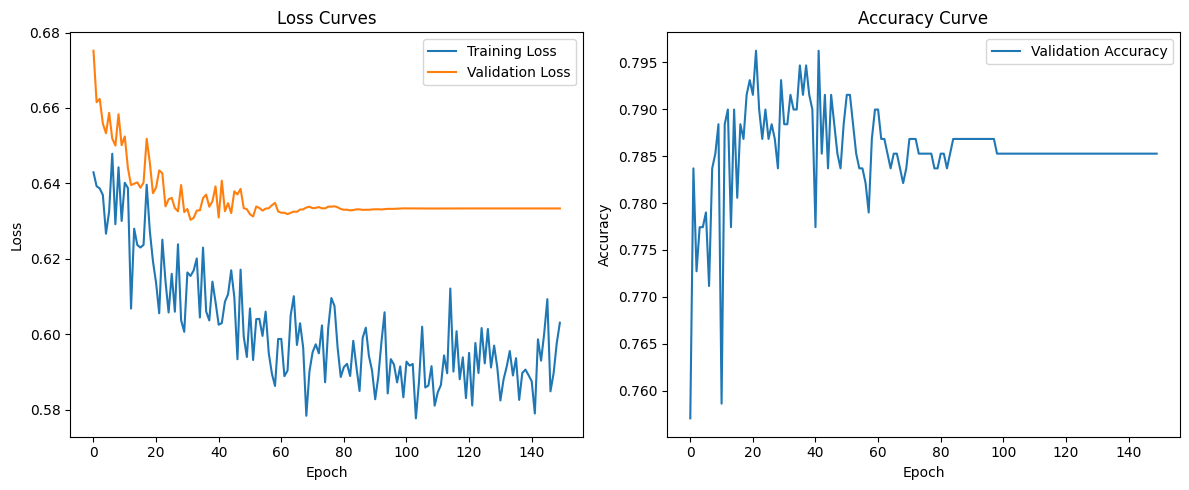

Using 32 epochs for final full-data fit.
Final fit epoch   1 | Train 0.7969
Final fit epoch  10 | Train 0.6431
Final fit epoch  20 | Train 0.6316
Final fit epoch  30 | Train 0.6282
Selected threshold for Income Investment: 0.400 (val F-beta=0.7029, beta=1.2)


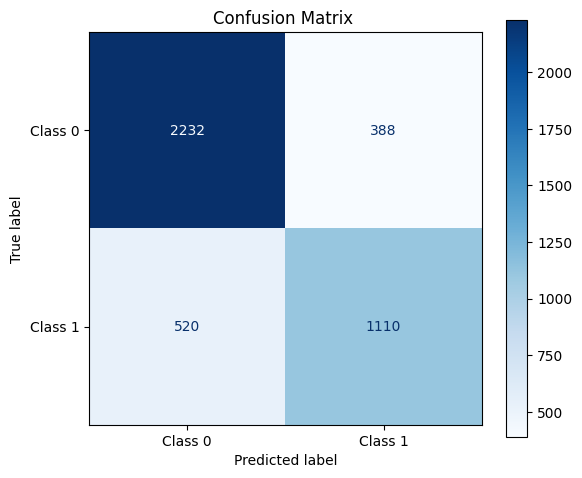

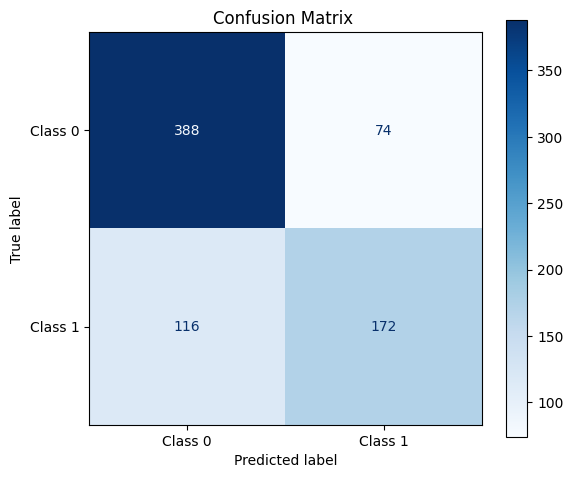


Final Metrics — Income Investment:
           Training (Full)  Final Test
accuracy             0.786       0.747
precision            0.741       0.699
recall               0.681       0.597
f1                   0.710       0.644


[I 2026-04-17 15:29:38,306] A new study created in memory with name: Accumulation Investment



Confusion Matrix:
[[388  74]
 [116 172]]

Optuna Search for: Accumulation Investment


Best trial: 0. Best value: 0.74186:   3%|▎         | 1/30 [00:04<02:12,  4.59s/it, 4.59/600 seconds]

[I 2026-04-17 15:29:42,892] Trial 0 finished with value: 0.7418604651162791 and parameters: {'n_layers': 2, 'units_l0': 80, 'units_l1': 112, 'dropout_l0': 0.42451898274987365, 'dropout_l1': 0.20607653492606257, 'use_batchnorm': True, 'optimizer': 'RMSprop', 'lr': 0.0001609126726319481, 'weight_decay': 3.722924540339833e-05, 'batch_size': 256}. Best is trial 0 with value: 0.7418604651162791.


...

[I 2026-04-17 15:33:15,151] Trial 27 finished with value: 0.8112965340179717 and parameters: {'n_layers': 3, 'units_l0': 128, 'units_l1': 80, 'units_l2': 96, 'dropout_l0': 0.4997099458658746, 'dropout_l1': 0.36783791307712377, 'dropout_l2': 0.39067565553668787, 'use_batchnorm': False, 'optimizer': 'Adam', 'lr': 0.002147394203537548, 'weight_decay': 0.0004797276561570274, 'batch_size': 128}. Best is trial 12 with value: 0.8113440197287299.


Best trial: 12. Best value: 0.811344:  97%|█████████▋| 29/30 [03:46<00:08,  8.44s/it, 226.89/600 seconds]

[I 2026-04-17 15:33:25,197] Trial 28 finished with value: 0.7750611246943765 and parameters: {'n_layers': 2, 'units_l0': 128, 'units_l1': 96, 'dropout_l0': 0.40368608094239483, 'dropout_l1': 0.3799220808363377, 'use_batchnorm': False, 'optimizer': 'RMSprop', 'lr': 0.0006256990534978678, 'weight_decay': 0.00043125017086375776, 'batch_size': 128}. Best is trial 12 with value: 0.8113440197287299.


Best trial: 12. Best value: 0.811344: 100%|██████████| 30/30 [03:58<00:00,  7.96s/it, 238.93/600 seconds]


[I 2026-04-17 15:33:37,234] Trial 29 finished with value: 0.4537037037037037 and parameters: {'n_layers': 3, 'units_l0': 64, 'units_l1': 32, 'units_l2': 96, 'dropout_l0': 0.41479319414426585, 'dropout_l1': 0.44977726773378157, 'dropout_l2': 0.4726852834182643, 'use_batchnorm': True, 'optimizer': 'SGD', 'lr': 0.0002642065038970494, 'weight_decay': 7.170723772151704e-05, 'batch_size': 128}. Best is trial 12 with value: 0.8113440197287299.

  Best validation F1: 0.8113

Monitoring refit on held-out split for Accumulation Investment...
Epoch  10 | Train 0.4636 | Val 0.4663 | Acc 0.7806
Epoch  20 | Train 0.4159 | Val 0.4217 | Acc 0.8119
Epoch  30 | Train 0.4079 | Val 0.4120 | Acc 0.8119
Epoch  40 | Train 0.3972 | Val 0.4091 | Acc 0.8072
Epoch  50 | Train 0.3905 | Val 0.4057 | Acc 0.8135
Epoch  60 | Train 0.3776 | Val 0.3975 | Acc 0.8276
Epoch  70 | Train 0.3680 | Val 0.3944 | Acc 0.8150
Epoch  80 | Train 0.3680 | Val 0.3951 | Acc 0.8213
Epoch  90 | Train 0.3667 | Val 0.3941 | Acc 0.8182
Epo

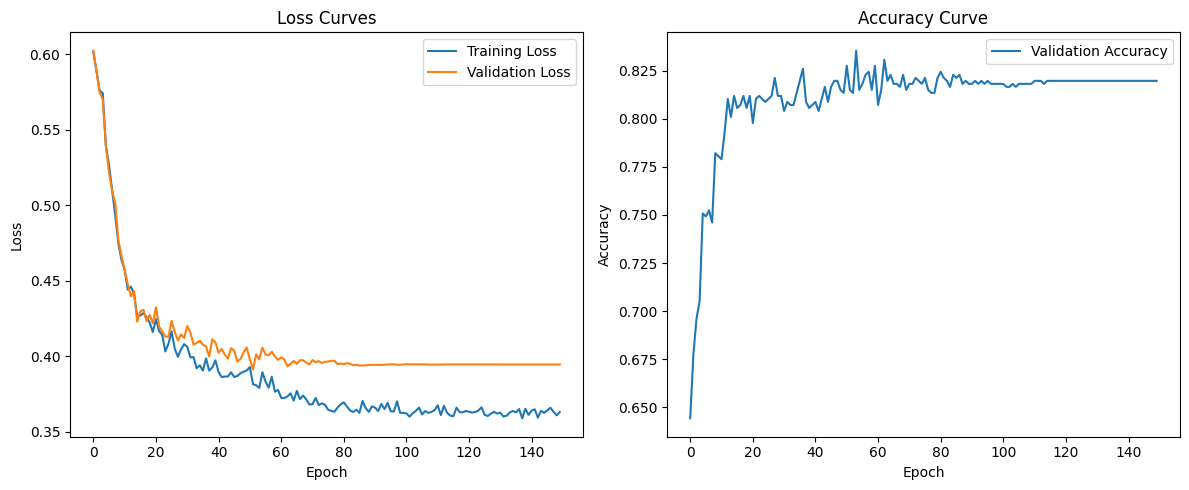

Using 52 epochs for final full-data fit.
Final fit epoch   1 | Train 0.6472
Final fit epoch  10 | Train 0.5206
Final fit epoch  20 | Train 0.4617
Final fit epoch  30 | Train 0.4397
Final fit epoch  40 | Train 0.4284
Final fit epoch  50 | Train 0.4258
Selected threshold for Accumulation Investment: 0.260 (val F-beta=0.8163, beta=1.0)


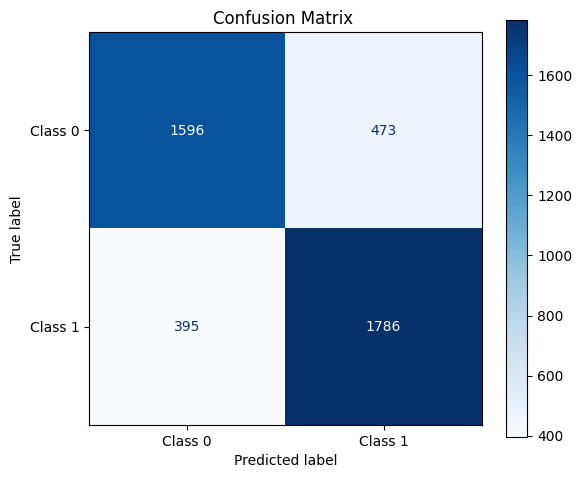

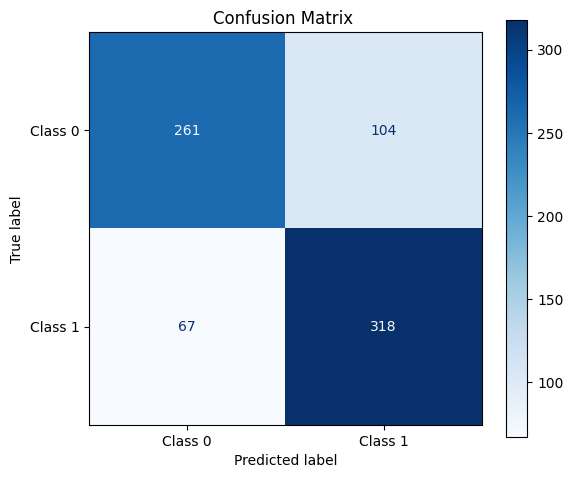


Final Metrics — Accumulation Investment:
           Training (Full)  Final Test
accuracy             0.796       0.772
precision            0.791       0.754
recall               0.819       0.826
f1                   0.805       0.788

Confusion Matrix:
[[261 104]
 [ 67 318]]


In [27]:
from sklearn.model_selection import train_test_split

best_mlp_params = {}
best_mlp_models = {}
best_mlp_thresholds = {}

def select_best_threshold(y_true, y_proba, beta=1.0):
    thresholds = np.linspace(0.20, 0.80, 61)
    best_t = 0.5
    best_score = -1.0

    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        score = fbeta_score(y_true, y_hat, beta=beta, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = float(t)

    return best_t, best_score

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\nOptuna Search for: {target_name}")
    print("=" * 50)

    # --- 1. Three-Way Split ---
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_engineered, y, test_size=0.15, random_state=42, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
    )

    input_size = X_train.shape[1]

    # --- 2. Optuna Search ---
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        study_name=target_name
    )

    study.optimize(
        make_objective(X_train, y_train, X_val, y_val, input_size),
        n_trials=30,
        timeout=600,
        show_progress_bar=True
    )

    print(f"\n  Best validation F1: {study.best_trial.value:.4f}")

    # --- 3. Refit monitor split + final full training ---
    X_refit_train, X_refit_val, y_refit_train, y_refit_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
    )

    p = study.best_trial.params
    n = p["n_layers"]
    best_layer_sizes = [p[f"units_l{i}"] for i in range(n)]
    best_dropouts = [p[f"dropout_l{i}"] for i in range(n)]

    best_model = MLP(input_size, best_layer_sizes, best_dropouts, p["use_batchnorm"]).to(device)
    best_optimizer = getattr(optim, p["optimizer"])(
        best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"]
    )

    best_mlp_models[target_name] = best_model
    best_mlp_params[target_name] = study.best_trial.params

    refit_train_loader = DataLoader(
        InvestmentDataset(X_refit_train, y_refit_train),
        batch_size=p["batch_size"],
        shuffle=True
    )
    refit_val_loader = DataLoader(
        InvestmentDataset(X_refit_val, y_refit_val),
        batch_size=p["batch_size"]
    )
    full_train_loader = DataLoader(
        InvestmentDataset(X_train_full, y_train_full),
        batch_size=p["batch_size"],
        shuffle=True
    )
    full_eval_loader = DataLoader(
        InvestmentDataset(X_train_full, y_train_full),
        batch_size=p["batch_size"]
    )
    test_loader = DataLoader(InvestmentDataset(X_test, y_test), batch_size=p["batch_size"])

    refit_criterion = make_weighted_criterion(y_refit_train)

    print(f"\nMonitoring refit on held-out split for {target_name}...")
    refit_result = train_model_with_curves(
        best_model,
        refit_train_loader,
        refit_val_loader,
        refit_criterion,
        best_optimizer,
        epochs=150,
        use_early_stopping=False,
        restore_best=True
    )
    best_epoch = max(20, refit_result["history"]["best_epoch"])
    print(f"Using {best_epoch} epochs for final full-data fit.")

    final_model = MLP(input_size, best_layer_sizes, best_dropouts, p["use_batchnorm"]).to(device)
    final_optimizer = getattr(optim, p["optimizer"])(
        final_model.parameters(), lr=p["lr"] * 0.5, weight_decay=p["weight_decay"]
    )
    final_criterion = make_weighted_criterion(y_train_full)
    final_model = train_final_model(
        final_model,
        full_train_loader,
        final_criterion,
        final_optimizer,
        epochs=best_epoch
    )

    # Calibrate threshold on refit validation split (boost recall where needed)
    val_proba = predict_mlp_proba(final_model, refit_val_loader)
    beta = 1.2 if target_name == 'Income Investment' else 1.0
    best_threshold, best_thr_score = select_best_threshold(y_refit_val.values, val_proba, beta=beta)
    best_mlp_thresholds[target_name] = best_threshold
    print(f"Selected threshold for {target_name}: {best_threshold:.3f} (val F-beta={best_thr_score:.4f}, beta={beta})")

    best_mlp_models[target_name] = final_model

    # --- 4. Final Unbiased Metrics ---
    train_metrics = evaluate_nn_metrics(final_model, full_eval_loader, threshold=best_threshold)
    test_metrics = evaluate_nn_metrics(final_model, test_loader, threshold=best_threshold)

    metrics_df = pd.DataFrame({'Training (Full)': train_metrics, 'Final Test': test_metrics}).round(3)
    print(f"\nFinal Metrics — {target_name}:\n{metrics_df}")

    # Confusion Matrix with tuned threshold
    final_model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            y_raw = final_model(X_batch).squeeze()
            y_proba = torch.sigmoid(y_raw)
            all_preds.extend((y_proba > best_threshold).float().cpu().numpy())
    cm = confusion_matrix(y_test, all_preds)
    print(f"\nConfusion Matrix:\n{cm}")

## Utility for tuned MLP inference
The next cell defines a fixed dataset wrapper and prediction function for neural network outputs.

In [28]:
class InvestmentDatasetFixed(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values.copy())
        if isinstance(y, torch.Tensor):
            self.y = y
        else:
            self.y = torch.FloatTensor(y.values.copy())

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def get_target_mlp_threshold(target_name=None, fallback=0.5):
    """Resolve per-target MLP threshold, defaulting to 0.5 if unavailable."""
    if target_name is not None and 'best_mlp_thresholds' in globals():
        return float(best_mlp_thresholds.get(target_name, fallback))
    return float(fallback)


def get_predictions_from_mlp(model, X_test, threshold=None, target_name=None):
    if threshold is None:
        threshold = get_target_mlp_threshold(target_name=target_name, fallback=0.5)

    dummy_y = pd.Series(np.zeros(len(X_test)))
    test_dataset = InvestmentDatasetFixed(X_test, dummy_y)
    test_loader = DataLoader(test_dataset, batch_size=128)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            y_raw = model(X_batch).squeeze()
            if globals().get('MLP_OUTPUT_IS_LOGITS', False):
                y_proba = torch.sigmoid(y_raw)
            else:
                y_proba = y_raw
            all_preds.extend((y_proba > threshold).float().cpu().numpy())
    return np.array(all_preds)

## AutoML for tree models
Tune Random Forest and XGBoost with Optuna and stores the best models.

In [29]:
# --- AutoML Optuna Tuning for Random Forest and XGBoost ---

# Ensure reproducibility seed exists even if this cell is run standalone
if 'SEED' not in globals():
    SEED = 42

def make_rf_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 500, step=50)
        max_depth = trial.suggest_int("max_depth", 5, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
        
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight='balanced',
            random_state=SEED,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        return fbeta_score(y_val, y_pred, beta=1)
    return objective

def make_xgb_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 500, step=50)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True)
        reg_lambda = trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True)
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=SEED,
            eval_metric='logloss',
            verbosity=0
        )
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_val)
        return fbeta_score(y_val, y_pred, beta=1)
    return objective

# Store best models for later ensemble
best_rf_models = {}
best_xgb_models = {}

for target_name, y in [('Income Investment', y_income), ('Accumulation Investment', y_accum)]:
    print(f"\n{'='*70}")
    print(f"AutoML Tuning for: {target_name}")
    print(f"{'='*70}")
    
    X_train, X_test, y_train, y_test = split_data(X_engineered, y)
    
    # --- Random Forest Tuning ---
    print(f"\n Tuning Random Forest for {target_name}...")
    print("-" * 70)
    rf_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        study_name=f"RF_{target_name}"
    )
    rf_study.optimize(
        make_rf_objective(X_train, y_train, X_test, y_test),
        n_trials=20,
        timeout=300,
        show_progress_bar=True
    )
    
    rf_pruned = rf_study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    rf_complete = rf_study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    
    print(f"  Trials completed: {len(rf_study.trials)}")
    print(f"  Pruned: {len(rf_pruned)}, Completed: {len(rf_complete)}")
    print(f"  Best F1 Score: {rf_study.best_trial.value:.4f}")
    print("  Best params:")
    for k, v in rf_study.best_trial.params.items():
        print(f"    {k}: {v}")
    
    # Train best RF model
    rf_params = rf_study.best_trial.params
    best_rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_split=rf_params["min_samples_split"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
    best_rf.fit(X_train, y_train)
    best_rf_models[target_name] = best_rf
    
    rf_pred_train = best_rf.predict(X_train)
    rf_pred_test = best_rf.predict(X_test)
    rf_metrics = {
        'Accuracy':  accuracy_score(y_test, rf_pred_test),
        'Precision': precision_score(y_test, rf_pred_test),
        'Recall':    recall_score(y_test, rf_pred_test),
        'F1':        f1_score(y_test, rf_pred_test),
        'AUC':       roc_auc_score(y_test, rf_pred_test)
    }
    print(f"\n  Random Forest Test Metrics:")
    print(f"   {pd.DataFrame({'Test': rf_metrics}).round(3).to_string()}")
    
    # --- XGBoost Tuning ---
    print(f"\nTuning XGBoost for {target_name}...")
    print("-" * 70)
    xgb_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        study_name=f"XGB_{target_name}"
    )
    xgb_study.optimize(
        make_xgb_objective(X_train, y_train, X_test, y_test),
        n_trials=20,
        timeout=300,
        show_progress_bar=True
    )
    
    xgb_pruned = xgb_study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    xgb_complete = xgb_study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    
    print(f"  Trials completed: {len(xgb_study.trials)}")
    print(f"  Pruned: {len(xgb_pruned)}, Completed: {len(xgb_complete)}")
    print(f"  Best F1 Score: {xgb_study.best_trial.value:.4f}")
    print("  Best params:")
    for k, v in xgb_study.best_trial.params.items():
        print(f"    {k}: {v}")
    
    # Train best XGBoost model
    xgb_params = xgb_study.best_trial.params
    best_xgb = xgb.XGBClassifier(
        n_estimators=xgb_params["n_estimators"],
        max_depth=xgb_params["max_depth"],
        learning_rate=xgb_params["learning_rate"],
        subsample=xgb_params["subsample"],
        colsample_bytree=xgb_params["colsample_bytree"],
        reg_alpha=xgb_params["reg_alpha"],
        reg_lambda=xgb_params["reg_lambda"],
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    )
    best_xgb.fit(X_train, y_train)
    best_xgb_models[target_name] = best_xgb
    
    xgb_pred_train = best_xgb.predict(X_train)
    xgb_pred_test = best_xgb.predict(X_test)
    xgb_metrics = {
        'Accuracy':  accuracy_score(y_test, xgb_pred_test),
        'Precision': precision_score(y_test, xgb_pred_test),
        'Recall':    recall_score(y_test, xgb_pred_test),
        'F1':        f1_score(y_test, xgb_pred_test),
        'AUC':       roc_auc_score(y_test, xgb_pred_test)
    }
    print(f"\n  XGBoost Test Metrics:")
    print(f"   {pd.DataFrame({'Test': xgb_metrics}).round(3).to_string()}")
    
    print(f"\n{'='*70}")
    print(f"Tuning Complete for {target_name}")
    print(f"{'='*70}")

[I 2026-04-17 15:34:23,550] A new study created in memory with name: RF_Income Investment



AutoML Tuning for: Income Investment

 Tuning Random Forest for Income Investment...
----------------------------------------------------------------------


Best trial: 0. Best value: 0.652038:  10%|█         | 2/20 [00:00<00:04,  3.83it/s, 0.56/300 seconds]

[I 2026-04-17 15:34:23,940] Trial 0 finished with value: 0.6520376175548589 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6520376175548589.
[I 2026-04-17 15:34:24,111] Trial 1 finished with value: 0.6510903426791277 and parameters: {'n_estimators': 100, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.6520376175548589.


Best trial: 2. Best value: 0.653907:  15%|█▌        | 3/20 [00:01<00:07,  2.36it/s, 1.18/300 seconds]

...

[I 2026-04-17 15:34:52,221] Trial 17 finished with value: 0.8058151609553479 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.01616233205630123, 'subsample': 0.9186007623689508, 'colsample_bytree': 0.7019815317958183, 'reg_alpha': 0.0771768651299863, 'reg_lambda': 0.13770074733627205}. Best is trial 16 with value: 0.82389289392379.


Best trial: 16. Best value: 0.823893:  95%|█████████▌| 19/20 [00:03<00:00,  3.86it/s, 3.68/300 seconds]

[I 2026-04-17 15:34:52,540] Trial 18 finished with value: 0.8158168574401665 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.010172530443898495, 'subsample': 0.8307796695558711, 'colsample_bytree': 0.600621159959812, 'reg_alpha': 0.0028347611077517267, 'reg_lambda': 0.0006193717941683596}. Best is trial 16 with value: 0.82389289392379.


Best trial: 16. Best value: 0.823893: 100%|██████████| 20/20 [00:03<00:00,  5.04it/s, 3.97/300 seconds]


[I 2026-04-17 15:34:52,830] Trial 19 finished with value: 0.8130745658835546 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.0456047757292357, 'subsample': 0.8916739739336339, 'colsample_bytree': 0.6945572341016742, 'reg_alpha': 0.9640551424298529, 'reg_lambda': 0.012738334915573418}. Best is trial 16 with value: 0.82389289392379.
  Trials completed: 20
  Pruned: 0, Completed: 20
  Best F1 Score: 0.8239
  Best params:
    n_estimators: 300
    max_depth: 6
    learning_rate: 0.017038383004753972
    subsample: 0.819513547550795
    colsample_bytree: 0.7148583767286517
    reg_alpha: 0.03156007043625973
    reg_lambda: 0.020539293099750562

  XGBoost Test Metrics:
               Test
Accuracy   0.829
Precision  0.873
Recall     0.780
F1         0.824
AUC        0.830

Tuning Complete for Accumulation Investment


## Build ensemble pipelines
OOF probabilities, voting/stacking ensembles, and meta-models with tuned thresholds.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.base import clone

def get_oof_predictions(model, X_train, y_train, k_folds=5):
    """Returns out-of-fold predicted probabilities for the train set."""
    kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    oof_proba = np.zeros(len(X_train))

    for train_idx, val_idx in kf.split(X_train,y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]

        m_fold = clone(model)
        m_fold.fit(X_tr, y_tr)
        oof_proba[val_idx] = m_fold.predict_proba(X_val)[:, 1]

    return oof_proba

def get_probas_from_mlp(model, X):
    """Extracts probabilities from the neural network (supports logits and sigmoid outputs)."""
    dummy_y = pd.Series(np.zeros(len(X)))
    loader  = DataLoader(InvestmentDatasetFixed(X, dummy_y), batch_size=128)
    model.eval()
    all_probas = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            y_raw = model(X_batch).squeeze()
            if globals().get('MLP_OUTPUT_IS_LOGITS', False):
                y_proba = torch.sigmoid(y_raw)
            else:
                y_proba = y_raw
            all_probas.extend(y_proba.cpu().numpy())
    return np.array(all_probas)

def get_oof_predictions_nn_tuned(X_train, y_train, best_params, input_size, k_folds=5):
    """OOF probabilities using the tuned MLP architecture & hyperparams."""
    kf        = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    oof_proba = np.zeros(len(X_train))
    p = best_params

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train,y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]

        fold_loader = DataLoader(
            InvestmentDatasetFixed(X_tr, y_tr),
            batch_size=p["batch_size"],
            shuffle=True,
        )

        layer_sizes = [p[f"units_l{i}"] for i in range(p["n_layers"])]
        dropouts    = [p[f"dropout_l{i}"] for i in range(p["n_layers"])]

        fold_model = MLP(input_size, layer_sizes, dropouts, p["use_batchnorm"]).to(device)
        optimizer  = getattr(optim, p["optimizer"])(fold_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
        criterion  = make_weighted_criterion(y_tr)

        fold_model.train()
        for _ in range(100):
            for X_batch, y_batch in fold_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                y_raw = fold_model(X_batch).squeeze()
                loss = criterion(y_raw, y_batch)
                loss.backward()
                optimizer.step()

        oof_proba[val_idx] = get_probas_from_mlp(fold_model, X_val)
    return oof_proba

def select_threshold_near_best_f1_max_recall(y_true, y_prob, f1_tolerance=0.02):
    """
    Pick the threshold with highest recall among thresholds whose F1 is
    within (1 - f1_tolerance) of the best F1.
    """
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return {
            "threshold": 0.5,
            "precision": float(precision[0]),
            "recall": float(recall[0]),
            "f1": 0.0,
            "best_f1": 0.0,
        }

    precision = precision[:-1]
    recall = recall[:-1]
    f1 = 2.0 * precision * recall / (precision + recall + 1e-12)
    best_f1 = float(np.max(f1))

    eligible = np.where(f1 >= best_f1 * (1 - f1_tolerance))[0]
    if len(eligible) == 0:
        idx = int(np.argmax(f1))
    else:
        idx = int(eligible[np.argmax(recall[eligible])])

    return {
        "threshold": float(thresholds[idx]),
        "precision": float(precision[idx]),
        "recall": float(recall[idx]),
        "f1": float(f1[idx]),
        "best_f1": best_f1,
    }

def evaluate_ensemble(y_true, y_pred, y_proba, label):
    """Returns a column of metrics for a given prediction set."""
    return {
        f"{label}": {
            "Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred),
            "F1":        f1_score(y_true, y_pred),
            "AUC":       roc_auc_score(y_true, y_proba),
        }
    }

# Store trained stacking meta-learners for downstream recommendation blocks
meta_models = {}
ensemble_thresholds = {}

# -- MAIN ENSEMBLE LOOP
for target_name, y in [("Income Investment", y_income), ("Accumulation Investment", y_accum)]:
    print(f"\n{'='*80}")
    print(f" ENSEMBLE ANALYSIS: {target_name}")
    print(f"{'='*80}")

    X_train, X_test, y_train, y_test = split_data(X_engineered, y)

    mlp_target_threshold = 0.5
    if 'best_mlp_thresholds' in globals():
        mlp_target_threshold = float(best_mlp_thresholds.get(target_name, 0.5))

    # 1. Compute OOF Predictions for Meta-Learner & OOF Voting
    print(f"--- Step 1: Generating OOF Probabilities (k={5}) ---")
    rf_oof  = get_oof_predictions(best_rf_models[target_name], X_train, y_train)
    xgb_oof = get_oof_predictions(best_xgb_models[target_name], X_train, y_train)
    mlp_oof = get_oof_predictions_nn_tuned(X_train, y_train, best_mlp_params[target_name], X_train.shape[1])

    # 2. Evaluation: OOF Voting (Internal validation)
    print(f"\n--- Step 2: OOF Voting Metrics (Train Set) ---")

    # OOF Hard (Majority Binary, MLP uses calibrated per-target threshold)
    oof_hard_pred = ((rf_oof >= 0.5).astype(int) + (xgb_oof >= 0.5).astype(int) + (mlp_oof >= mlp_target_threshold).astype(int) >= 2).astype(int)
    # OOF Soft (Average Probability with tuned threshold)
    oof_soft_proba = (rf_oof + xgb_oof + mlp_oof) / 3
    soft_threshold_info = select_threshold_near_best_f1_max_recall(y_train, oof_soft_proba, f1_tolerance=0.02)
    oof_soft_pred  = (oof_soft_proba >= soft_threshold_info["threshold"]).astype(int)

    metrics_oof = {}
    metrics_oof.update(evaluate_ensemble(y_train, oof_hard_pred, oof_hard_pred, "OOF Hard"))
    metrics_oof.update(evaluate_ensemble(y_train, oof_soft_pred, oof_soft_proba, "OOF Soft"))
    print(pd.DataFrame(metrics_oof).round(3))
    print(f"  MLP threshold for hard voting: {mlp_target_threshold:.4f}")
    print(f"  Soft-voting threshold (near-best F1 / max recall): {soft_threshold_info['threshold']:.4f}")

    # 3. Evaluation: Voting on Test Set (External validation)
    print(f"\n--- Step 3: Voting Metrics (Test Set) ---")

    test_rf_proba  = best_rf_models[target_name].predict_proba(X_test)[:, 1]
    test_xgb_proba = best_xgb_models[target_name].predict_proba(X_test)[:, 1]
    test_mlp_proba = get_probas_from_mlp(best_mlp_models[target_name], X_test)

    # Test Hard
    test_hard_pred = ((test_rf_proba >= 0.5).astype(int) + (test_xgb_proba >= 0.5).astype(int) + (test_mlp_proba >= mlp_target_threshold).astype(int) >= 2).astype(int)
    # Test Soft (same threshold tuned on OOF probabilities)
    test_soft_proba = (test_rf_proba + test_xgb_proba + test_mlp_proba) / 3
    test_soft_pred  = (test_soft_proba >= soft_threshold_info["threshold"]).astype(int)

    metrics_voting = {}
    metrics_voting.update(evaluate_ensemble(y_test, test_hard_pred, test_hard_pred, "Test Hard"))
    metrics_voting.update(evaluate_ensemble(y_test, test_soft_pred, test_soft_proba, "Test Soft"))
    print(pd.DataFrame(metrics_voting).round(3))

    # 4. Evaluation: Stacking (Meta-Learner)
    print(f"\n--- Step 4: Stacking Metrics (Logistic Regression Meta-Learner) ---")

    meta_train = np.column_stack([rf_oof, xgb_oof, mlp_oof])
    meta_test  = np.column_stack([test_rf_proba, test_xgb_proba, test_mlp_proba])

    meta_model = LogisticRegression(random_state=SEED)
    meta_model.fit(meta_train, y_train)

    stacking_train_proba = meta_model.predict_proba(meta_train)[:, 1]
    stacking_threshold_info = select_threshold_near_best_f1_max_recall(
        y_train, stacking_train_proba, f1_tolerance=0.02
    )

    stacking_proba = meta_model.predict_proba(meta_test)[:, 1]
    stacking_pred  = (stacking_proba >= stacking_threshold_info["threshold"]).astype(int)

    metrics_stack = evaluate_ensemble(y_test, stacking_pred, stacking_proba, "Stacking")
    print(pd.DataFrame(metrics_stack).round(3))
    print(f"  Stacking threshold (near-best F1 / max recall): {stacking_threshold_info['threshold']:.4f}")

    # Save meta-learner and tuned thresholds for downstream recommendations
    meta_models[target_name] = meta_model
    ensemble_thresholds[target_name] = {
        "soft_voting": soft_threshold_info,
        "stacking": stacking_threshold_info,
    }

    print(f"\n{'='*80}")


 ENSEMBLE ANALYSIS: Income Investment
--- Step 1: Generating OOF Probabilities (k=5) ---

--- Step 2: OOF Voting Metrics (Train Set) ---
           OOF Hard  OOF Soft
Accuracy      0.825     0.802
Precision     0.881     0.793
Recall        0.630     0.653
F1            0.734     0.716
AUC           0.788     0.798
  MLP threshold for hard voting: 0.4000
  Soft-voting threshold (near-best F1 / max recall): 0.3847

--- Step 3: Voting Metrics (Test Set) ---
           Test Hard  Test Soft
Accuracy       0.785      0.762
Precision      0.848      0.750
Recall         0.536      0.570
F1             0.657      0.648
AUC            0.738      0.756

--- Step 4: Stacking Metrics (Logistic Regression Meta-Learner) ---
           Stacking
Accuracy      0.771
Precision     0.780
Recall        0.562
F1            0.654
AUC           0.752
  Stacking threshold (near-best F1 / max recall): 0.3211


 ENSEMBLE ANALYSIS: Accumulation Investment
--- Step 1: Generating OOF Probabilities (k=5) ---

---

## Run model interpretability analysis
The next cell applies feature importance, SHAP, and LIME to the best models for each target.


############################################################
 INTERPRETABILITY ANALYSIS: Income Investment
############################################################

>>> Analyzing Random Forest for Income Investment
----------------------------------------
Generating Feature Importance for Random Forest...


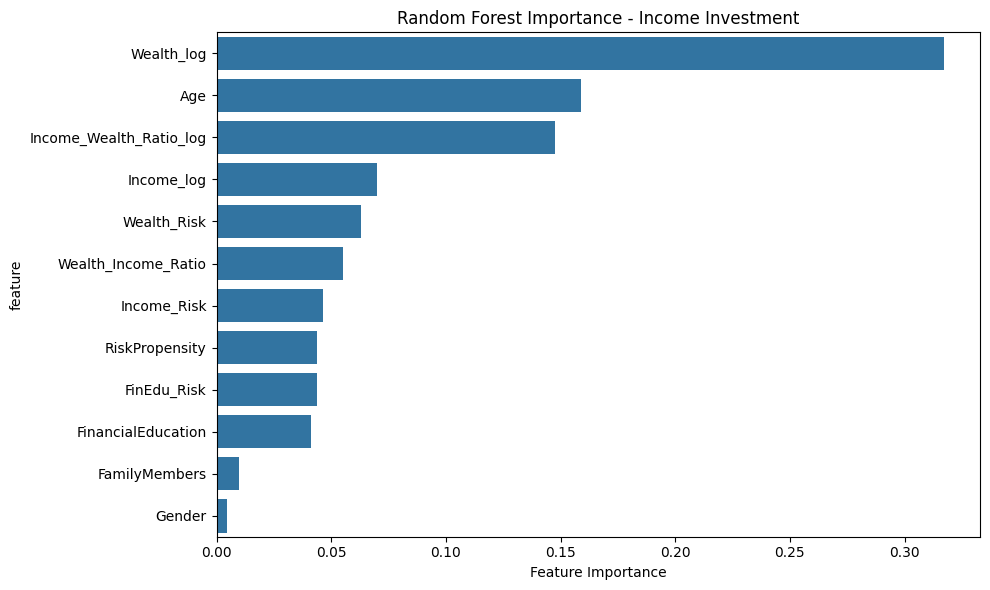

Generating SHAP Analysis for Random Forest...
SHAP failed for Random Forest: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for Random Forest...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


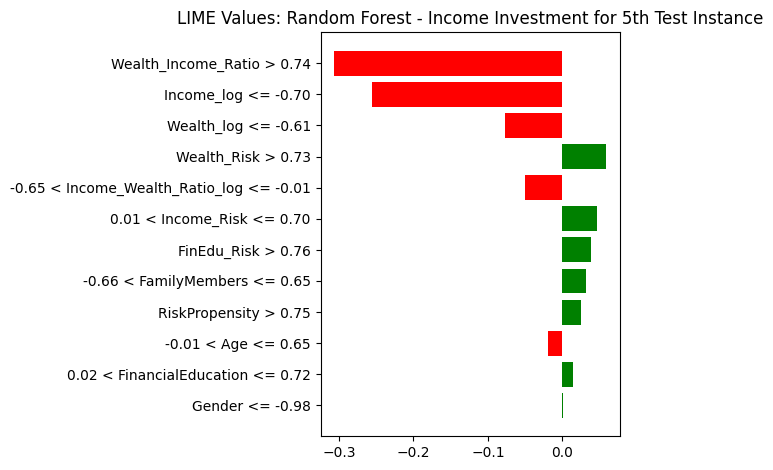


>>> Analyzing XGBoost for Income Investment
----------------------------------------
Generating Feature Importance for XGBoost...


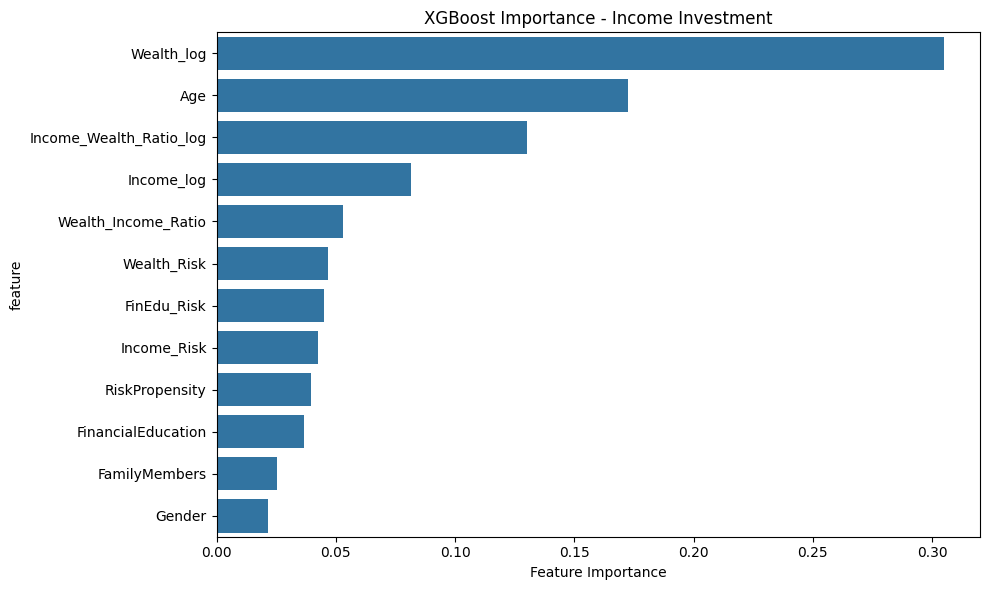

Generating SHAP Analysis for XGBoost...
SHAP failed for XGBoost: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for XGBoost...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


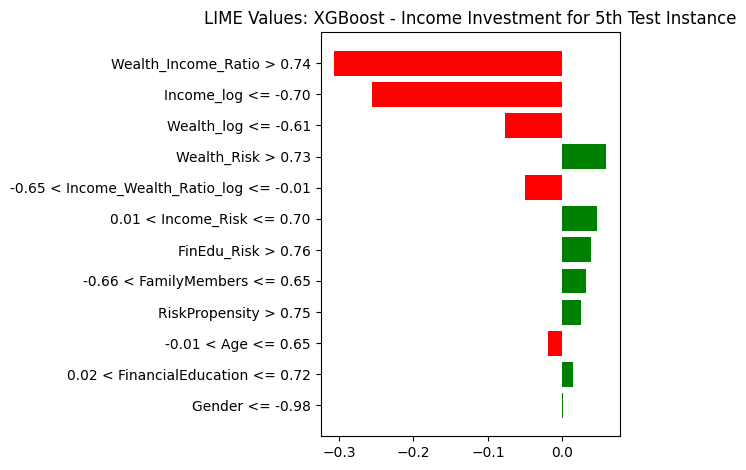


>>> Analyzing MLP (Neural Net) for Income Investment
----------------------------------------
Generating SHAP Analysis for MLP (Neural Net)...
SHAP failed for MLP (Neural Net): Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for MLP (Neural Net)...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


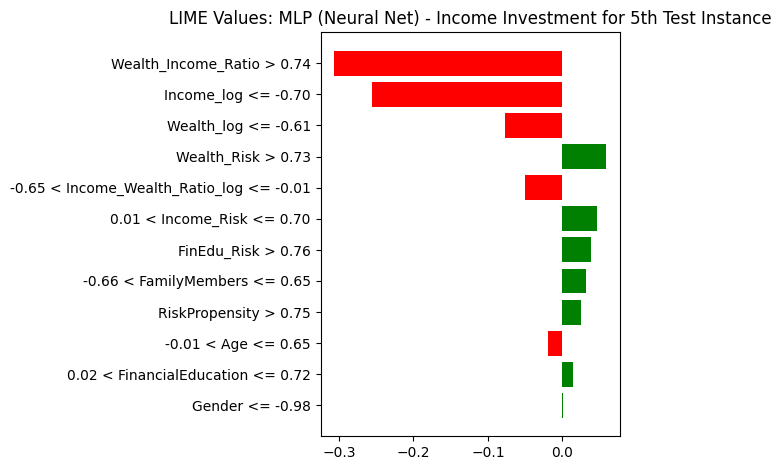



############################################################
 INTERPRETABILITY ANALYSIS: Accumulation Investment
############################################################

>>> Analyzing Random Forest for Accumulation Investment
----------------------------------------
Generating Feature Importance for Random Forest...


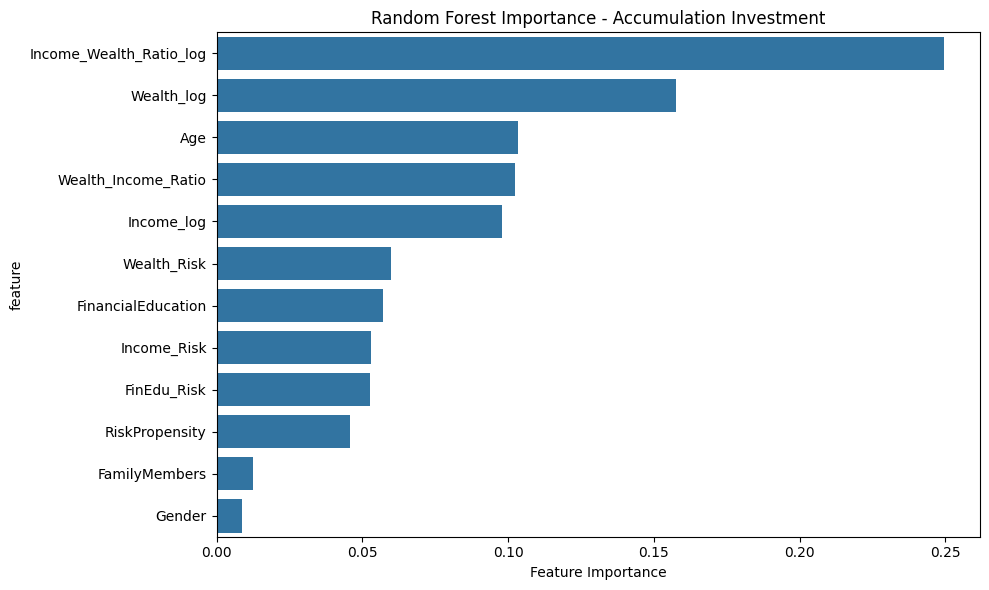

Generating SHAP Analysis for Random Forest...
SHAP failed for Random Forest: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for Random Forest...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


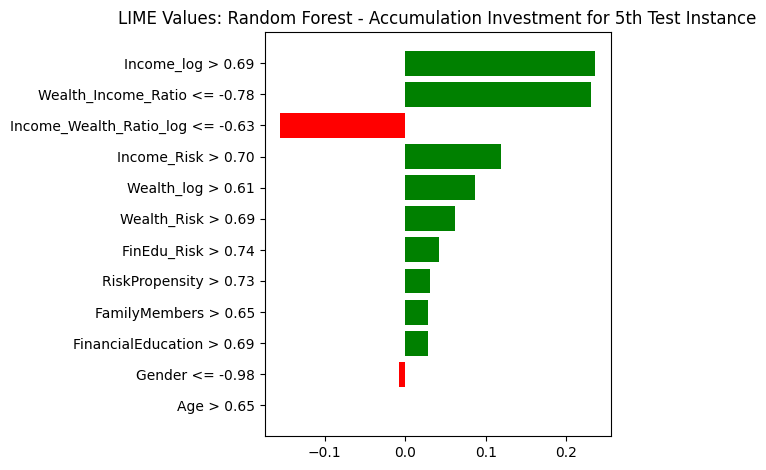


>>> Analyzing XGBoost for Accumulation Investment
----------------------------------------
Generating Feature Importance for XGBoost...


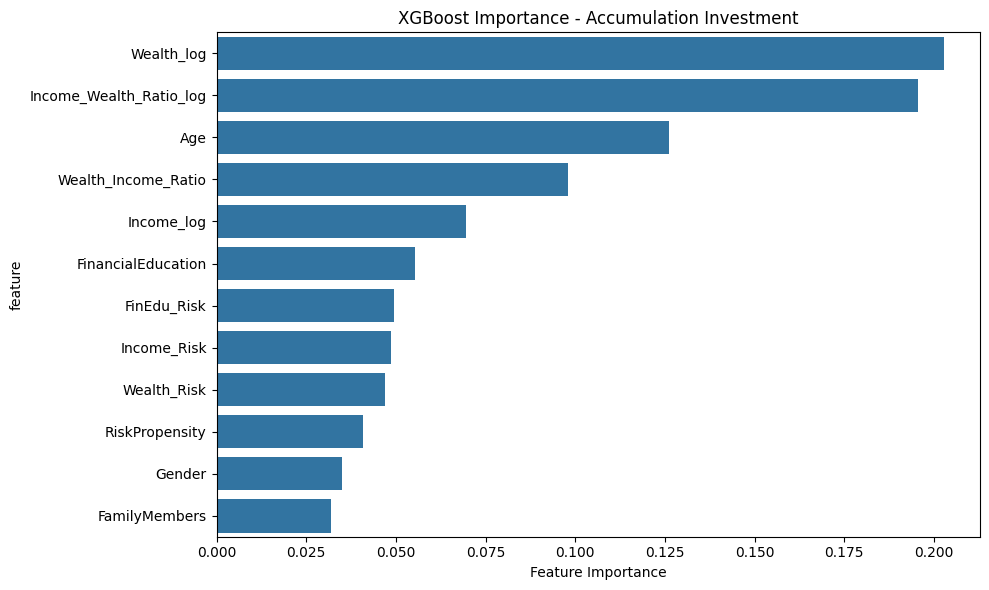

Generating SHAP Analysis for XGBoost...
SHAP failed for XGBoost: Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for XGBoost...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


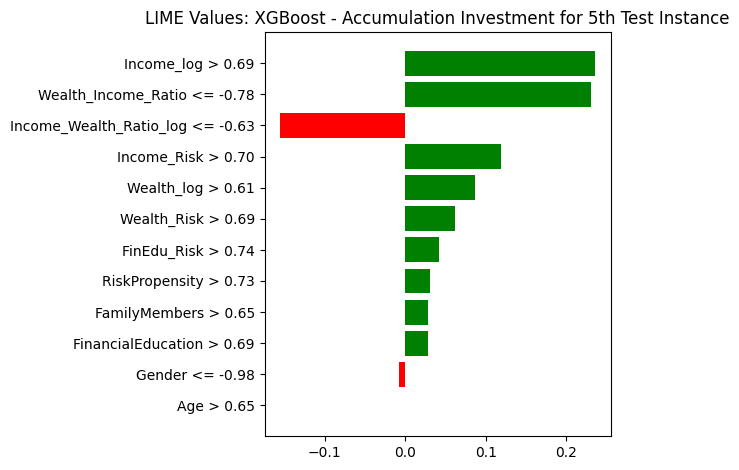


>>> Analyzing MLP (Neural Net) for Accumulation Investment
----------------------------------------
Generating SHAP Analysis for MLP (Neural Net)...
SHAP failed for MLP (Neural Net): Model type not yet supported by TreeExplainer: <class 'sklearn.naive_bayes.GaussianNB'>
Generating LIME Analysis for MLP (Neural Net)...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


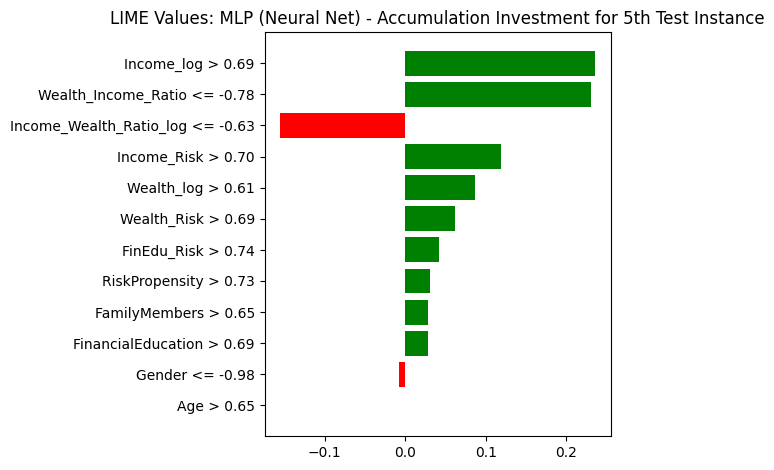

In [31]:
# Qui stampiamo i modelli migliori per ogni target e facciamo un'analisi di interpretabilità approfondita su ciascuno di essi, partendo dai modelli più performanti (Random Forest, XGBoost, MLP) 
# e applichiamo sia feature importance che SHAP e LIME per capire le decisioni del modello a livello globale e locale (ossia per una singola previsione, ho messo 5 come numero di esempi da analizzare localmente, ma si può aumentare o diminuire a seconda delle esigenze).

interpretability_targets = [
    ('Income Investment', y_income), 
    ('Accumulation Investment', y_accum)
]

for target_name, y in interpretability_targets:
    print(f"\n{'#'*60}")
    print(f" INTERPRETABILITY ANALYSIS: {target_name}")
    print(f"{'#'*60}")

    # Ensure we use the same split as the training phase
    X_eng_train, X_eng_test, y_train, y_test = split_data(X_engineered, y)
    
    # Define the models we want to interpret for this specific target
    current_models = {
        'Random Forest': best_rf_models[target_name],
        'XGBoost': best_xgb_models[target_name],
        'MLP (Neural Net)': best_mlp_models[target_name]
    }

    for model_name, model in current_models.items():
        print(f"\n>>> Analyzing {model_name} for {target_name}")
        print("-" * 40)

        # 1. Feature Importance (Only for Tree-based models)
        if hasattr(model, 'feature_importances_'):
            print(f"Generating Feature Importance for {model_name}...")
            plot_feature_importance(model, X_engineered.columns, f'{model_name} Importance - {target_name}')

        # 2. SHAP Analysis (Works for all, but uses different explainers)
        print(f"Generating SHAP Analysis for {model_name}...")
        try:
            plot_loc_shap_values(model, X_eng_test, f'SHAP Values: {model_name} - {target_name}', 5)
        except Exception as e:
            print(f"SHAP failed for {model_name}: {e}")

        # 3. LIME Analysis
        print(f"Generating LIME Analysis for {model_name}...")
        try:
            plot_loc_lime_values(model, X_eng_test, f'LIME Values: {model_name} - {target_name}', 5)
        except Exception as e:
            print(f"LIME failed for {model_name}: {e}")
            
    print("\n" + "="*60)

## Generate personalized recommendations
Predict client needs with the ensemble and prepare product recommendation inputs.

In [32]:
# Filter products by type
accumulation_products = products_df[products_df['Type'] == 1].copy()
income_products = products_df[products_df['Type'] == 0].copy()

# Min risk values (used later in matching logic)
min_risk_accum = accumulation_products['Risk'].min()
min_risk_income = income_products['Risk'].min()

print("\nGenerating predictions with the FULL ensemble (OOF + Stacking)")
print("=" * 80)

# Prepare features once
X_base, _ = prepare_features(needs_df)

def get_ensemble_predictions(target_name, X, use_stacking=True, return_proba=False):
    """
    Returns predictions from the ensemble.
    - use_stacking=True: use saved logistic meta-learner
    - use_stacking=False: use soft-voting average
    - return_proba=True: return probabilities instead of hard labels
    """
    if target_name not in best_rf_models or target_name not in best_xgb_models or target_name not in best_mlp_models:
        raise KeyError(f"Missing base model(s) for target: {target_name}")

    rf_proba  = best_rf_models[target_name].predict_proba(X)[:, 1]
    xgb_proba = best_xgb_models[target_name].predict_proba(X)[:, 1]
    mlp_proba = get_probas_from_mlp(best_mlp_models[target_name], X)

    if use_stacking:
        if 'meta_models' not in globals() or target_name not in meta_models:
            raise RuntimeError(
                f"Meta-learner for '{target_name}' not found. Run the ensemble loop cell first."
            )
        meta_features = np.column_stack([rf_proba, xgb_proba, mlp_proba])
        proba = meta_models[target_name].predict_proba(meta_features)[:, 1]
        if return_proba:
            return proba

        threshold = 0.5
        if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
            threshold = ensemble_thresholds[target_name].get('stacking', {}).get('threshold', 0.5)
        return (proba >= threshold).astype(int)

    soft_proba = (rf_proba + xgb_proba + mlp_proba) / 3
    if return_proba:
        return soft_proba

    threshold = 0.5
    if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
        threshold = ensemble_thresholds[target_name].get('soft_voting', {}).get('threshold', 0.5)
    return (soft_proba >= threshold).astype(int)

# Compute predictions for both needs with the saved ensemble pipeline
ensemble_results = {}
targets = [
    ('Income Investment', needs_df['IncomeInvestment']),
    ('Accumulation Investment', needs_df['AccumulationInvestment'])
]

for target_name, y_target in targets:
    X_train, X_test, y_train, y_test = split_data(X_engineered, y_target)
    y_pred = get_ensemble_predictions(target_name, X_test, use_stacking=True, return_proba=False)
    y_proba = get_ensemble_predictions(target_name, X_test, use_stacking=True, return_proba=True)

    ensemble_results[target_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'meta_model': meta_models[target_name]
    }
    if 'ensemble_thresholds' in globals() and target_name in ensemble_thresholds:
        thr = ensemble_thresholds[target_name]['stacking']['threshold']
        print(f"{target_name}: threshold={thr:.4f}, predicted positives = {int(y_pred.sum())}/{len(y_pred)}")
    else:
        print(f"{target_name}: predicted positives = {int(y_pred.sum())}/{len(y_pred)}")

# Backward-compatible variables used by downstream recommendation cells
X_test = ensemble_results['Accumulation Investment']['X_test']
y_pred = ensemble_results['Accumulation Investment']['y_pred']

# Explicit outputs for both needs
y_pred_accum = ensemble_results['Accumulation Investment']['y_pred']
y_pred_income = ensemble_results['Income Investment']['y_pred']
y_proba_accum = ensemble_results['Accumulation Investment']['y_proba']
y_proba_income = ensemble_results['Income Investment']['y_proba']


Generating predictions with the FULL ensemble (OOF + Stacking)
Income Investment: threshold=0.3211, predicted positives = 277/1000
Accumulation Investment: threshold=0.3269, predicted positives = 537/1000


## Risk-based client-product matching
The next cell assigns at most one suitable product per client under strict risk constraints and summarizes diagnostics.


Recommendation rows generated:
Accumulation (all clients in split): 1000
Income (all clients in split): 1000
Total: 2000
Accumulation targeted positives: 537
Income targeted positives: 277

No-recommendation count (client risk below minimum product risk):
Accumulation unmatched count: 307
Income unmatched count: 42

Suitability violations (must be 0):
Accumulation violations: 0
Income violations: 0

Top 10 accumulation recommendations (all clients):
   ClientID  RecommendedProductID  ClientRiskPropensity  ProductRiskLevel  \
0      3879                     9              0.273216              0.27   
1       741                     9              0.336864              0.27   
2      3151                     0              0.263229               NaN   
3      4159                     9              0.326331              0.27   
4      4920                     0              0.166667               NaN   
5      2352                     1              0.567415              0.55   
6     

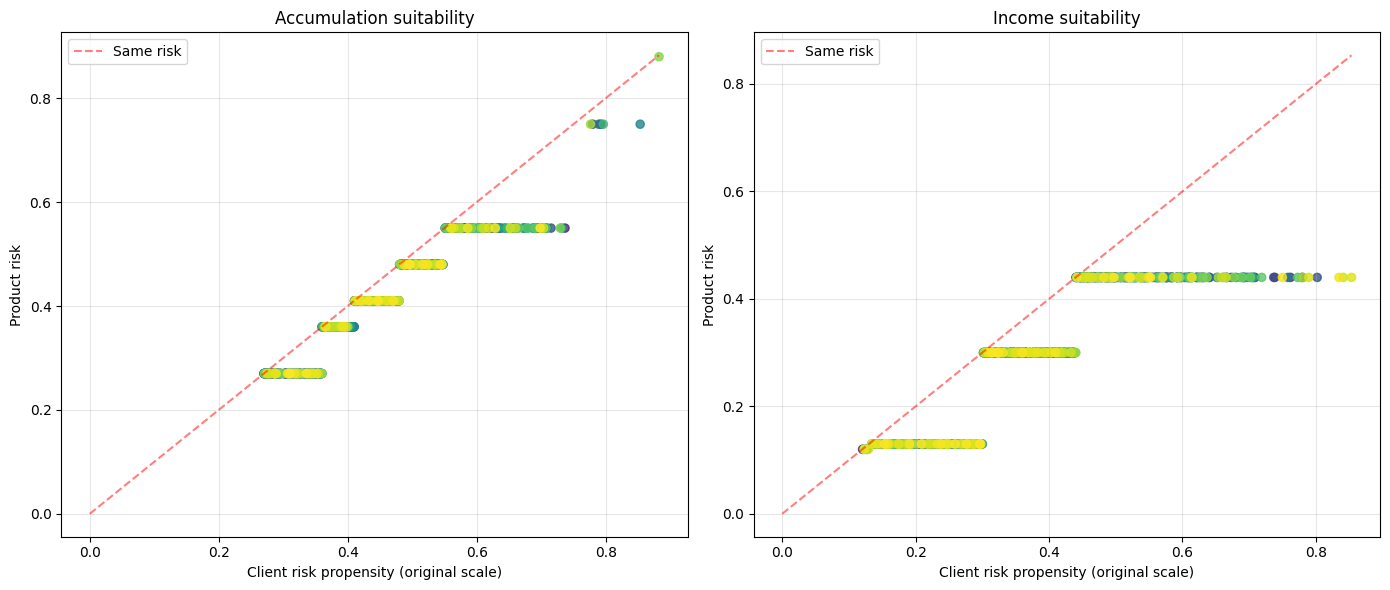

In [33]:
def build_recommendations_for_all_clients(X_clients, products_subset, need_type, reference_df):
    """
    Recommend at most one product per client using strict suitability.
    Rule: highest product risk <= client risk.
    If no feasible product exists, no recommendation is assigned (ID=0).
    """
    product_ids = products_subset['IDProduct'].astype(np.uint16).values
    product_risks = products_subset['Risk'].astype(float).values

    # Sort products once to make threshold search deterministic and efficient
    order = np.argsort(product_risks)
    product_ids_sorted = product_ids[order]
    product_risks_sorted = product_risks[order]

    client_ids = X_clients.index.values
    # IMPORTANT: use ORIGINAL risk scale (not MinMax-scaled X_base risk)
    client_risks = reference_df.loc[client_ids, 'RiskPropensity'].astype(float).values

    recommended_ids = []
    recommended_risks = []
    feasible_flags = []

    eps = 1e-12  # numerical tolerance
    for client_risk in client_risks:
        feasible_mask = product_risks_sorted <= (client_risk + eps)
        if feasible_mask.any():
            best_idx = np.where(feasible_mask)[0][-1]  # highest feasible risk
            recommended_ids.append(product_ids_sorted[best_idx])
            recommended_risks.append(product_risks_sorted[best_idx])
            feasible_flags.append(True)
        else:
            # Strict suitability: no recommendation if every product is too risky
            recommended_ids.append(0)
            recommended_risks.append(np.nan)
            feasible_flags.append(False)

    return pd.DataFrame({
        'ClientID': client_ids,
        'RecommendedProductID': recommended_ids,
        'ClientRiskPropensity': client_risks,
        'ProductRiskLevel': recommended_risks,
        'NeedType': need_type,
        'FeasibleWithoutFallback': feasible_flags
    })

# Build recommendation datasets from ensemble outputs
X_test_accum = ensemble_results['Accumulation Investment']['X_test']
X_test_income = ensemble_results['Income Investment']['X_test']

# 1) All-clients-by-need recommendation with strict risk suitability (original risk scale)
nba_accum_all_clients = build_recommendations_for_all_clients(
    X_test_accum, accumulation_products, 'Accumulation', needs_df
)
nba_income_all_clients = build_recommendations_for_all_clients(
    X_test_income, income_products, 'Income', needs_df
)

# 2) Predicted-positive subsets (aligned by client index to ensemble labels)
accum_pred_series = pd.Series(y_pred_accum, index=X_test_accum.index)
income_pred_series = pd.Series(y_pred_income, index=X_test_income.index)
nba_accum_targeted = nba_accum_all_clients.loc[accum_pred_series.loc[nba_accum_all_clients['ClientID']].values == 1].copy()
nba_income_targeted = nba_income_all_clients.loc[income_pred_series.loc[nba_income_all_clients['ClientID']].values == 1].copy()

# Keep old variable names backward-compatible
nba_accum = nba_accum_all_clients.copy()
nba_income = nba_income_all_clients.copy()
nba_all = pd.concat([nba_accum, nba_income], ignore_index=True)
nba = nba_accum.copy()

print("\nRecommendation rows generated:")
print(f"Accumulation (all clients in split): {len(nba_accum_all_clients)}")
print(f"Income (all clients in split): {len(nba_income_all_clients)}")
print(f"Total: {len(nba_all)}")
print(f"Accumulation targeted positives: {len(nba_accum_targeted)}")
print(f"Income targeted positives: {len(nba_income_targeted)}")

# Unmatched diagnostics under strict suitability
acc_unmatched = (~nba_accum_all_clients['FeasibleWithoutFallback']).sum()
inc_unmatched = (~nba_income_all_clients['FeasibleWithoutFallback']).sum()
print(f"\nNo-recommendation count (client risk below minimum product risk):")
print(f"Accumulation unmatched count: {acc_unmatched}")
print(f"Income unmatched count: {inc_unmatched}")

# Hard suitability checks on recommended rows
acc_violations = (
    nba_accum_all_clients.loc[nba_accum_all_clients['RecommendedProductID'] > 0, 'ProductRiskLevel']
    > nba_accum_all_clients.loc[nba_accum_all_clients['RecommendedProductID'] > 0, 'ClientRiskPropensity'] + 1e-12
).sum()
inc_violations = (
    nba_income_all_clients.loc[nba_income_all_clients['RecommendedProductID'] > 0, 'ProductRiskLevel']
    > nba_income_all_clients.loc[nba_income_all_clients['RecommendedProductID'] > 0, 'ClientRiskPropensity'] + 1e-12
).sum()
print(f"\nSuitability violations (must be 0):")
print(f"Accumulation violations: {int(acc_violations)}")
print(f"Income violations: {int(inc_violations)}")

print("\nTop 10 accumulation recommendations (all clients):")
print(nba_accum_all_clients.head(10))

print("\nTop 10 income recommendations (all clients):")
print(nba_income_all_clients.head(10))

# Suitability check plots for both need types (only recommended points)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_plot, title in [
    (axes[0], nba_accum_all_clients, 'Accumulation suitability'),
    (axes[1], nba_income_all_clients, 'Income suitability')
  ]:
    df_rec = df_plot[df_plot['RecommendedProductID'] > 0].copy()
    if len(df_rec) > 0:
        ax.scatter(
            df_rec['ClientRiskPropensity'],
            df_rec['ProductRiskLevel'],
            c=range(len(df_rec)),
            cmap='viridis',
            alpha=0.8,
            s=35
        )
    y_max = df_rec['ProductRiskLevel'].max() if len(df_rec) > 0 else 0.0
    max_val = max(df_plot['ClientRiskPropensity'].max(), y_max)
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Same risk')
    ax.set_title(title)
    ax.set_xlabel('Client risk propensity (original scale)')
    ax.set_ylabel('Product risk')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Analyze recommendation outcomes
Coverage, product-frequency distributions, and summary statistics of generated recommendations.


Recommendation statistics - Accumulation (all clients)
Total clients analyzed: 1000
Clients with recommendations: 693 (69.30%)
Clients without feasible product: 307


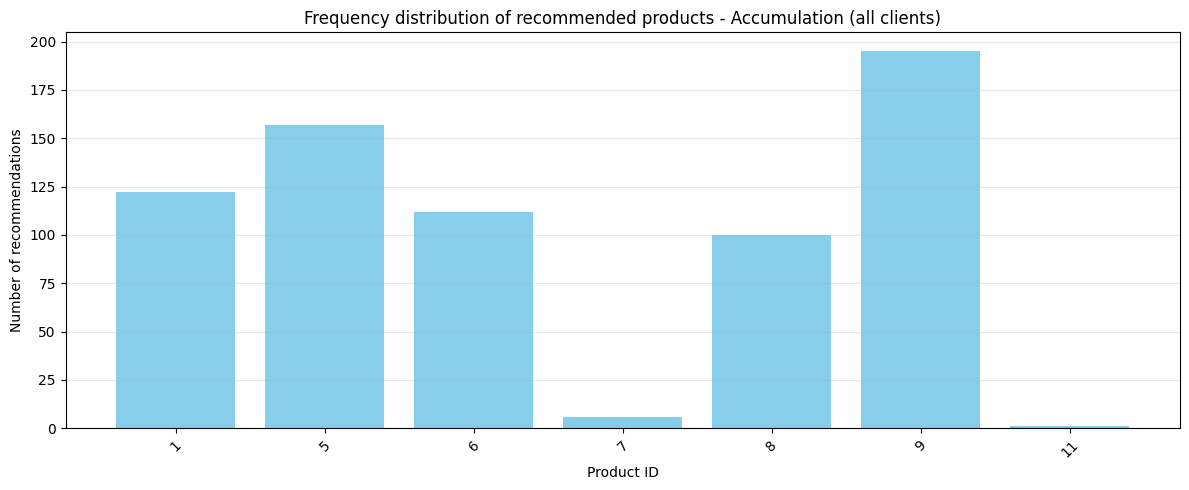


Details on the most recommended products:

Product ID: 9
Risk: 0.27
Recommended to 195 clients

Product ID: 5
Risk: 0.41
Recommended to 157 clients

Product ID: 1
Risk: 0.55
Recommended to 122 clients

Recommendation statistics - Income (all clients)
Total clients analyzed: 1000
Clients with recommendations: 958 (95.80%)
Clients without feasible product: 42


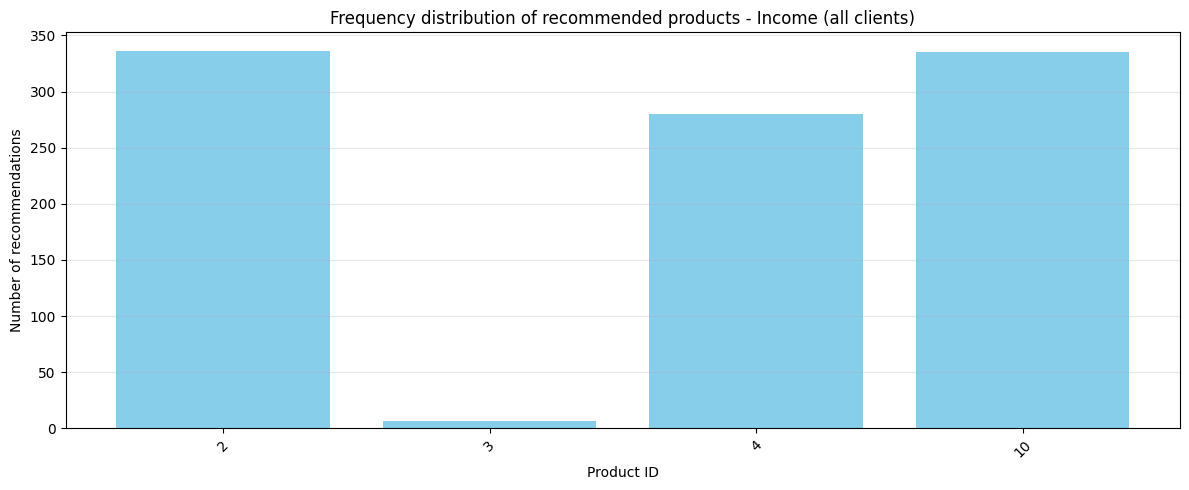


Details on the most recommended products:

Product ID: 2
Risk: 0.3
Recommended to 336 clients

Product ID: 10
Risk: 0.13
Recommended to 335 clients

Product ID: 4
Risk: 0.44
Recommended to 280 clients

Overall recommendation summary
Accumulation targeted rows: 537
Income targeted rows: 277
Total recommendations: 814


In [34]:
def analyze_recommendations(nba_df, products_subset, need_label):
    print(f"\n{'=' * 80}")
    print(f"Recommendation statistics - {need_label}")
    print(f"{'=' * 80}")

    total_clients = len(nba_df)
    clients_with_recommendations = len(nba_df[nba_df['RecommendedProductID'] > 0])
    pct_with_recommendations = (clients_with_recommendations / total_clients * 100) if total_clients > 0 else 0.0

    unmatched_count = 0
    if 'FeasibleWithoutFallback' in nba_df.columns:
        unmatched_count = (~nba_df['FeasibleWithoutFallback']).sum()

    print(f"Total clients analyzed: {total_clients}")
    print(
        f"Clients with recommendations: {clients_with_recommendations} "
        f"({pct_with_recommendations:.2f}%)"
    )
    print(f"Clients without feasible product: {unmatched_count}")

    if clients_with_recommendations == 0:
        print("No products were recommended in this segment.")
        return

    recommendation_counts = nba_df['RecommendedProductID'].value_counts().sort_index()
    recommendation_counts = recommendation_counts[recommendation_counts.index > 0]

    plt.figure(figsize=(12, 5))
    plt.bar(recommendation_counts.index.astype(str), recommendation_counts.values, color='skyblue')
    plt.title(f'Frequency distribution of recommended products - {need_label}')
    plt.xlabel('Product ID')
    plt.ylabel('Number of recommendations')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_products = recommendation_counts.nlargest(3).index
    print("\nDetails on the most recommended products:")
    for prod_id in top_products:
        product_details = products_subset[products_subset['IDProduct'] == prod_id]
        print(f"\nProduct ID: {prod_id}")
        print(f"Risk: {product_details['Risk'].values[0]}")
        print(f"Recommended to {recommendation_counts[prod_id]} clients")

# Analyze all-client recommendation streams
analyze_recommendations(nba_accum_all_clients, accumulation_products, 'Accumulation (all clients)')
analyze_recommendations(nba_income_all_clients, income_products, 'Income (all clients)')

# Combined high-level summary
print(f"\n{'=' * 80}")
print("Overall recommendation summary")
print(f"{'=' * 80}")
print(f"Accumulation targeted rows: {len(nba_accum_targeted)}")
print(f"Income targeted rows: {len(nba_income_targeted)}")
print(f"Total recommendations: {len(nba_accum_targeted) + len(nba_income_targeted)}")